In [0]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

In [0]:
nhs_suppliers_df = spark.read.table('my_catalog.bsheffield_spark.nhs_suppliers')
nhs_contract_description = spark.read.table('my_catalog.bsheffield_spark.nhs_contract_description')
nhs_trusts = spark.read.table('my_catalog.bsheffield_spark.nhs_trusts')
nhs_deliveries = spark.read.table('my_catalog.bsheffield_spark.nhs_deliveries')
nhs_costs_df = spark.read.table('my_catalog.bsheffield_spark.contracts_cost')

In [0]:
nhs_combo_df = nhs_suppliers_df \
    .select('supplier_id', 'supplier_name') \
    .join(nhs_contract_description, on='supplier_id', how='inner') \
    .join(nhs_trusts.select('trust_id', 'trust_name'), on='trust_id', how='inner') \
    .join(nhs_deliveries, on='contract_id', how='inner') \
    .join(nhs_costs_df, on='contract_id', how='inner')

In [0]:
nhs_combo_df.printSchema()

root
 |-- contract_id: string (nullable = true)
 |-- trust_id: string (nullable = true)
 |-- supplier_id: string (nullable = true)
 |-- supplier_name: string (nullable = true)
 |-- contract_type_id: string (nullable = true)
 |-- contract_type: string (nullable = true)
 |-- postcode: string (nullable = true)
 |-- issue_date: date (nullable = true)
 |-- closing_date: date (nullable = true)
 |-- trust_name: string (nullable = true)
 |-- quoted_lead_days: long (nullable = true)
 |-- actual_lead_days: long (nullable = true)
 |-- delivery_date: date (nullable = true)
 |-- quantity: long (nullable = true)
 |-- unit_cost: double (nullable = true)
 |-- quoted_cost: double (nullable = true)
 |-- actual_cost: double (nullable = true)
 |-- cost_overrun: double (nullable = true)



In [0]:
display(nhs_combo_df.limit(5))

contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun
NHS-CT-00001,TR-002,SUP-001,MedSupply UK,CTYP-006,Sharps Disposal,L9,2024-12-06,2024-12-31,Liverpool University Hospitals NHS FT,14,19,2025-01-19,100000,0.51,51101.26,51101.51,0.26
NHS-CT-00002,TR-005,SUP-002,BioLogica Ltd,CTYP-004,Reagent Bundles,FY3,2024-10-08,2024-10-19,Blackpool Teaching Hospitals NHS FT,29,34,2024-11-22,150,611.63,91745.0,92050.81,305.82
NHS-CT-00003,TR-002,SUP-002,BioLogica Ltd,CTYP-003,PCR Test Kits,L9,2025-03-30,2025-04-25,Liverpool University Hospitals NHS FT,15,15,2025-05-10,2000,11.88,23762.2,23762.2,0.0
NHS-CT-00004,TR-005,SUP-005,SterileFlow,CTYP-006,Sharps Disposal,FY1,2024-04-02,2024-04-24,Blackpool Teaching Hospitals NHS FT,10,13,2024-05-07,25000,0.38,9574.31,9574.42,0.11
NHS-CT-00005,TR-004,SUP-004,HealthLab Partners,CTYP-004,Reagent Bundles,PR2,2025-01-01,2025-01-17,Lancashire Teaching Hospitals NHS FT,14,16,2025-02-02,75,418.6,31394.96,31478.68,83.72


In [0]:
nhs_combo_df.select("trust_id").agg(F.countDistinct("trust_id")).show()
nhs_combo_df.select("supplier_id").agg(F.countDistinct("supplier_id")).show()

+------------------------+
|count(DISTINCT trust_id)|
+------------------------+
|                       5|
+------------------------+

+---------------------------+
|count(DISTINCT supplier_id)|
+---------------------------+
|                          5|
+---------------------------+



Need to examine:
1. Date/Time for issue date and closing date for contract (months/week number _?/Seasonality)
2. Encoding Postcode/Location of Delivery 
3. Encoding Contract Type 
4. Encoding Trust_id/name?

In [0]:
nhs_combo_df_pandas = nhs_combo_df.toPandas()

In [0]:
nhs_combo_df_pandas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contract_id       1000 non-null   object 
 1   trust_id          1000 non-null   object 
 2   supplier_id       1000 non-null   object 
 3   supplier_name     1000 non-null   object 
 4   contract_type_id  1000 non-null   object 
 5   contract_type     1000 non-null   object 
 6   postcode          1000 non-null   object 
 7   issue_date        1000 non-null   object 
 8   closing_date      1000 non-null   object 
 9   trust_name        1000 non-null   object 
 10  quoted_lead_days  1000 non-null   int64  
 11  actual_lead_days  1000 non-null   int64  
 12  delivery_date     1000 non-null   object 
 13  quantity          1000 non-null   int64  
 14  unit_cost         1000 non-null   float64
 15  quoted_cost       1000 non-null   float64
 16  actual_cost       1000 non-null   float64
 

In [0]:
nhs_combo_df_pandas.sample(4)

,contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun
600,NHS-CT-00601,TR-002,SUP-002,BioLogica Ltd,CTYP-003,PCR Test Kits,L7,2024-11-30,2024-12-16,Liverpool University Hospitals NHS FT,13,13,2024-12-29,5000,14.96,74817.19,74817.19,0.00
816,NHS-CT-00817,TR-003,SUP-002,BioLogica Ltd,CTYP-006,Sharps Disposal,WA7,2025-03-19,2025-04-14,Cheshire & Merseyside NHS FT,13,16,2025-04-30,50000,0.39,19619.01,19619.13,0.12
889,NHS-CT-00890,TR-001,SUP-005,SterileFlow,CTYP-004,Reagent Bundles,M15,2025-01-31,2025-02-19,Manchester University NHS FT,13,16,2025-03-07,50,538.65,26932.62,27094.21,161.60
269,NHS-CT-00270,TR-001,SUP-003,NorthWest Diagnostics,CTYP-006,Sharps Disposal,M13,2024-05-23,2024-06-14,Manchester University NHS FT,10,14,2024-06-28,50000,0.61,30450.44,30450.69,0.24


In [0]:
import random
from datetime import datetime, timedelta

In [0]:
import random
from datetime import datetime, timedelta

nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

In [0]:
nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

In [0]:
nhs_combo_df_pandas.sample()

,contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun,closing_date_month
370,NHS-CT-00371,TR-005,SUP-004,HealthLab Partners,CTYP-006,Sharps Disposal,FY3,2024-04-15,2024-05-07,Blackpool Teaching Hospitals NHS FT,7,7,2024-05-14,100000,0.34,34061.73,34061.73,0.0,May


In [0]:
nhs_combo_df_pandas['contract_type_id'].value_counts()

contract_type_id
CTYP-004    180
CTYP-005    180
CTYP-006    178
CTYP-002    163
CTYP-001    157
CTYP-003    142
Name: count, dtype: int64

### Try Classification for delivered on time

In [0]:
nhs_combo_df_pandas.sample(3)

,contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun,closing_date_month
173,NHS-CT-00174,TR-002,SUP-003,NorthWest Diagnostics,CTYP-006,Sharps Disposal,L14,2025-02-12,2025-03-02,Liverpool University Hospitals NHS FT,9,9,2025-03-11,25000,0.59,14827.54,14827.54,0.00,March
968,NHS-CT-00969,TR-004,SUP-004,HealthLab Partners,CTYP-004,Reagent Bundles,PR2,2025-03-24,2025-04-14,Lancashire Teaching Hospitals NHS FT,12,14,2025-04-28,50,283.76,14188.17,14244.92,56.75,April
545,NHS-CT-00546,TR-002,SUP-002,BioLogica Ltd,CTYP-004,Reagent Bundles,L14,2024-11-10,2024-11-20,Liverpool University Hospitals NHS FT,28,32,2024-12-22,100,683.31,68330.61,68603.93,273.32,November


In [0]:
def bin_delivery_target(df):
    if df['quoted_lead_days'] == df['actual_lead_days']:
        return 1
    else:
        return 0

In [0]:
nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
nhs_combo_df_pandas.sample(3)

,contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun,closing_date_month,bin_delivery_target
256,NHS-CT-00257,TR-002,SUP-002,BioLogica Ltd,CTYP-003,PCR Test Kits,L9,2024-06-03,2024-06-23,Liverpool University Hospitals NHS FT,9,11,2024-07-04,10000,14.15,141488.70,141491.53,2.83,June,0
875,NHS-CT-00876,TR-003,SUP-004,HealthLab Partners,CTYP-001,Blood Collection Kits,WA7,2024-10-08,2024-11-03,Cheshire & Merseyside NHS FT,4,4,2024-11-07,30000,1.33,39888.02,39888.02,0.00,November,1
216,NHS-CT-00217,TR-004,SUP-003,NorthWest Diagnostics,CTYP-005,Pipette Tips,PR1,2024-04-18,2024-05-18,Lancashire Teaching Hospitals NHS FT,7,8,2024-05-26,150000,0.02,3328.89,3328.89,0.00,May,0


<Axes: xlabel='bin_delivery_target', ylabel='count'>

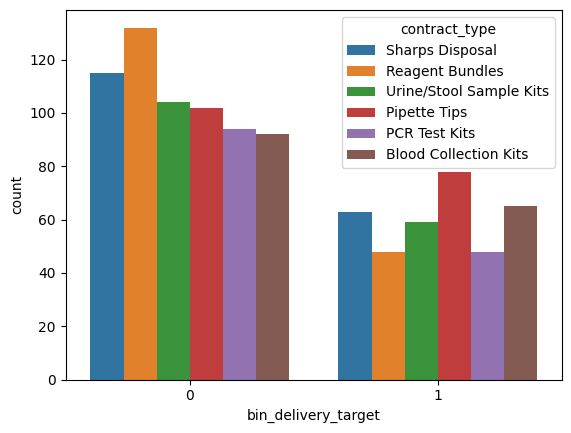

In [0]:
sns.countplot(x='bin_delivery_target', hue='contract_type', data=nhs_combo_df_pandas)

<Axes: xlabel='bin_delivery_target', ylabel='count'>

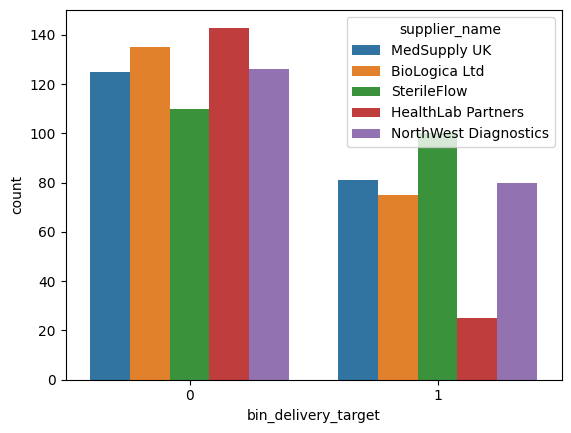

In [0]:
sns.countplot(x='bin_delivery_target', hue='supplier_name', data=nhs_combo_df_pandas)

<Axes: xlabel='actual_cost', ylabel='quantity'>

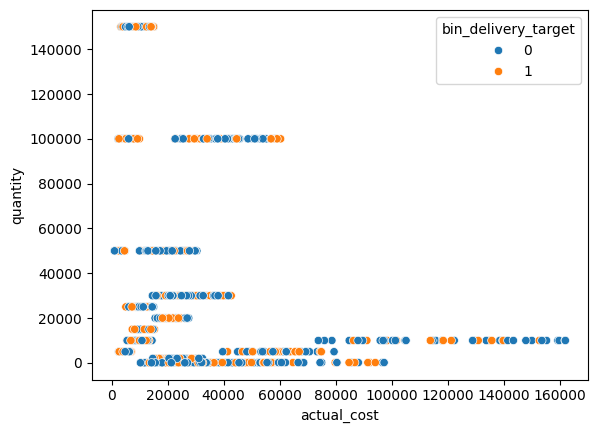

In [0]:
sns.scatterplot(x='actual_cost', y='quantity', hue='bin_delivery_target',data=nhs_combo_df_pandas)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'December'),
  Text(1, 0, 'October'),
  Text(2, 0, 'April'),
  Text(3, 0, 'January'),
  Text(4, 0, 'November'),
  Text(5, 0, 'September'),
  Text(6, 0, 'May'),
  Text(7, 0, 'August'),
  Text(8, 0, 'March'),
  Text(9, 0, 'June'),
  Text(10, 0, 'July'),
  Text(11, 0, 'February')])

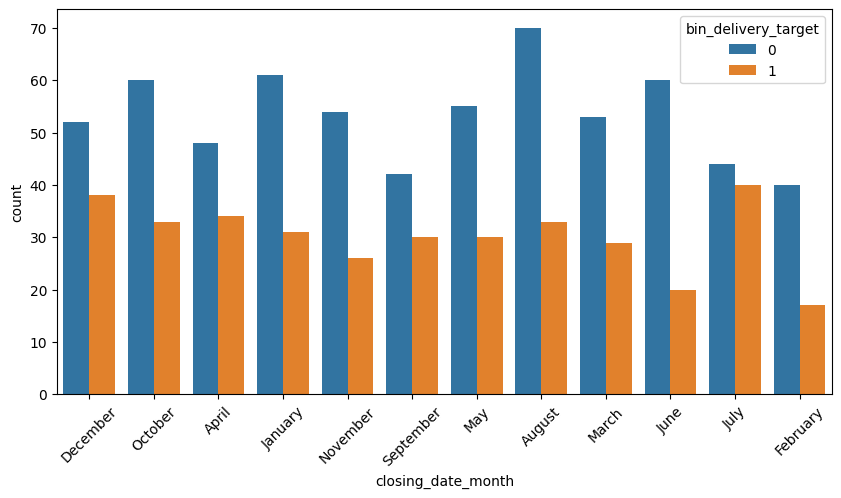

In [0]:
plt.figure(figsize=(10,5))
sns.countplot(x='closing_date_month', hue='bin_delivery_target', data=nhs_combo_df_pandas)
plt.xticks(rotation=45)

In [0]:
nhs_only_0 = nhs_combo_df_pandas.query('bin_delivery_target == 0')

ok now make percentage difference from quoted to actual

In [0]:
nhs_only_0['per_diff_qc_vs_ac'] = ((nhs_only_0['actual_cost'] - nhs_only_0['quoted_cost'])/nhs_only_0['actual_cost'])  * 100
nhs_only_0['per_diff_qt_vs_at'] = ((nhs_only_0['actual_lead_days'] - nhs_only_0['quoted_lead_days']) /nhs_only_0['actual_lead_days']) * 100

/home/spark-d87f34ae-a359-47fa-b147-0c/.ipykernel/2687/command-8425349576152584-3559725518:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nhs_only_0['per_diff_qc_vs_ac'] = ((nhs_only_0['actual_cost'] - nhs_only_0['quoted_cost'])/nhs_only_0['actual_cost'])  * 100
/home/spark-d87f34ae-a359-47fa-b147-0c/.ipykernel/2687/command-8425349576152584-3559725518:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nhs_only_0['per_diff_qt_vs_at'] = ((nhs_only_0['actual_lead_days'] - nhs_only_0['quoted_lead_days']) /nhs_o

In [0]:
nhs_only_0.groupby(['contract_type', "closing_date_month"])[['per_diff_qc_vs_ac', 'per_diff_qt_vs_at']].quantile([0.2, 0.4, 0.6, 0.8])

per_diff_qc_vs_ac  per_diff_qt_vs_at
contract_type           closing_date_month                                          
Blood Collection Kits   April              0.2           0.000993          20.000000
                                           0.4           0.001937          25.000000
                                           0.6           0.001960          25.000000
                                           0.8           0.001977          25.000000
                        August             0.2           0.000964          11.111111
...                                                           ...                ...
Urine/Stool Sample Kits October            0.8           0.004307          33.333333
                        September          0.2           0.000663          12.205128
                                           0.4           0.001233          20.000000
                                           0.6           0.005578          23.529412
                                           0.8           0.008377          28.333333

[288 rows x 2 columns]

## Classification For Timeframe

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output='pandas')

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, StackingClassifier


In [0]:
def datetime_change(df):
    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    # Encode using the classification target
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

def pp(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

def lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = LogisticRegression(class_weight='balanced')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1] # probability of delivering on time (1)

    # Classification metrics
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    lin_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_lin_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return lin_class_results_df, overall_lin_test_results_df, model, X_train_encoded, X_test_encoded, y_train, y_test


def lin_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

lin_class_results_df, overall_lin_test_results_df, model, X_train_encoded, X_test_encoded, y_train, y_test = lin_pipeline(nhs_combo_df_pandas)



In [0]:
lin_class_results_df.sample(5)

,Predicted,Actual,Predicted_Probability,Contract_type
1,1,1,0.548408,Urine/Stool Sample Kits
197,0,0,0.430720,PCR Test Kits
47,1,0,0.575462,PCR Test Kits
17,0,0,0.422716,PCR Test Kits
107,0,0,0.437491,Sharps Disposal


Text(0, 0.5, 'Contract Type')

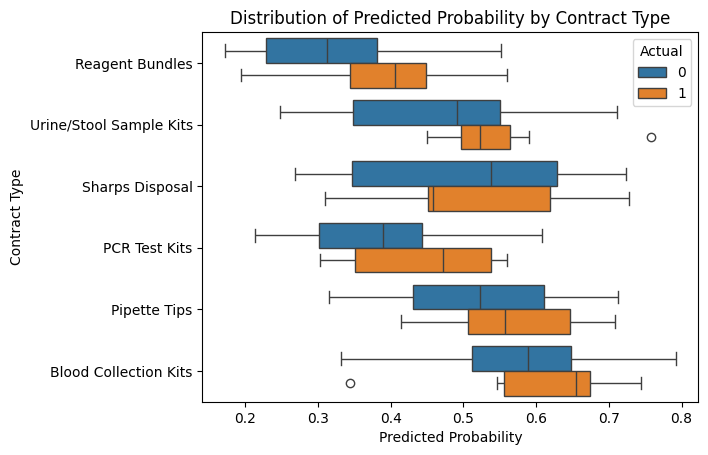

In [0]:
sns.boxplot(x='Predicted_Probability', y='Contract_type', hue='Actual', data=lin_class_results_df)
plt.title('Distribution of Predicted Probability by Contract Type')
plt.xlabel('Predicted Probability')
plt.ylabel('Contract Type')

<Axes: xlabel='Actual', ylabel='Predicted_Probability'>

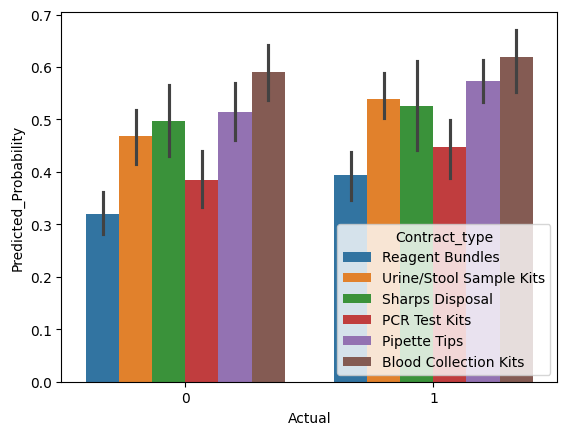

In [0]:
sns.barplot(y='Predicted_Probability', x='Actual', hue='Contract_type',data=lin_class_results_df)

In [0]:
overall_lin_test_results_df

,Accuracy,Precision,Recall,F1
0,0.605,0.5,0.594937,0.543353


### SHAP Linear

In [0]:
!pip install shap --upgrade -q
import shap
shap.initjs()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


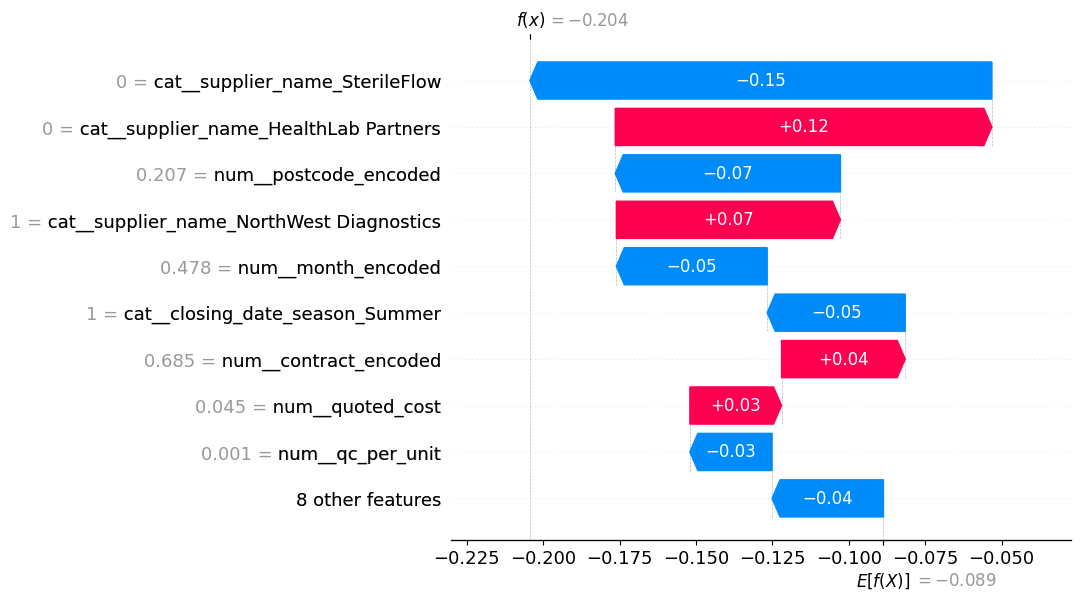

In [0]:
import shap

# Create SHAP explainer for logistic regression
explainer = shap.Explainer(model, X_train_encoded)

# Compute SHAP values for the test set
shap_values = explainer(X_test_encoded)

# Waterfall plot for the first prediction
shap.plots.waterfall(shap_values[2])


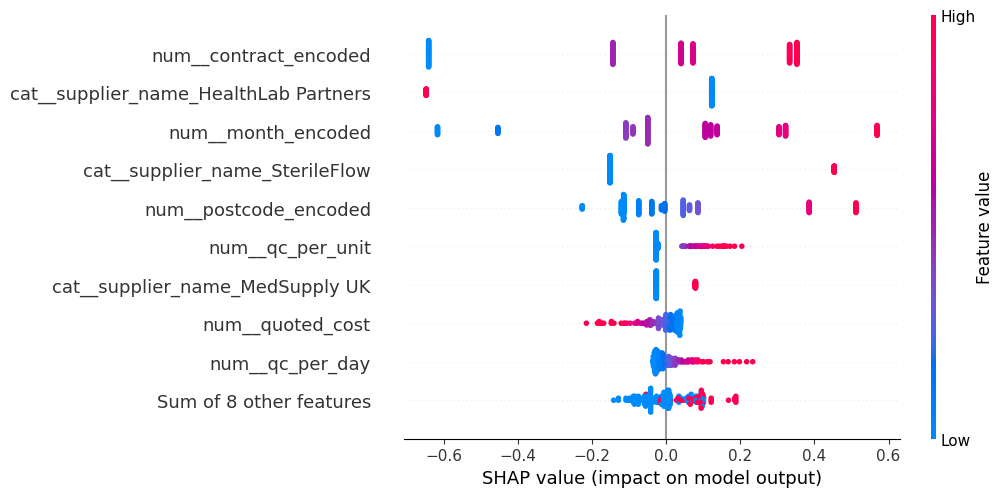

In [0]:
shap.plots.beeswarm(shap_values)


In [0]:
lin_class_results_df

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.235207,Reagent Bundles
1,1,1,0.548408,Urine/Stool Sample Kits
2,0,0,0.449092,Urine/Stool Sample Kits
3,1,1,0.500252,Urine/Stool Sample Kits
4,1,0,0.711863,Urine/Stool Sample Kits
...,...,...,...,...
195,0,0,0.484333,Sharps Disposal
196,0,1,0.472515,PCR Test Kits
197,0,0,0.430720,PCR Test Kits
198,0,0,0.428670,Sharps Disposal


<Axes: xlabel='Predicted_Probability', ylabel='Count'>

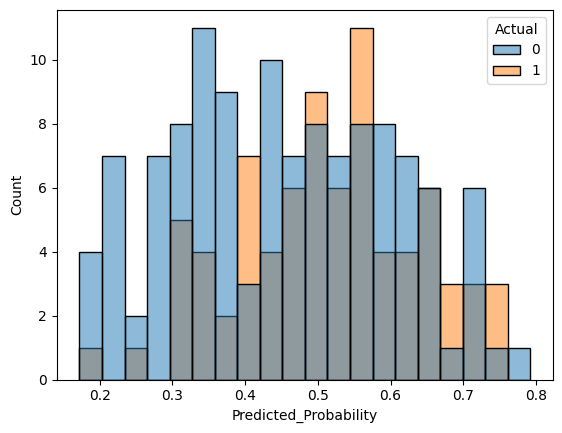

In [0]:
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df, bins=20)


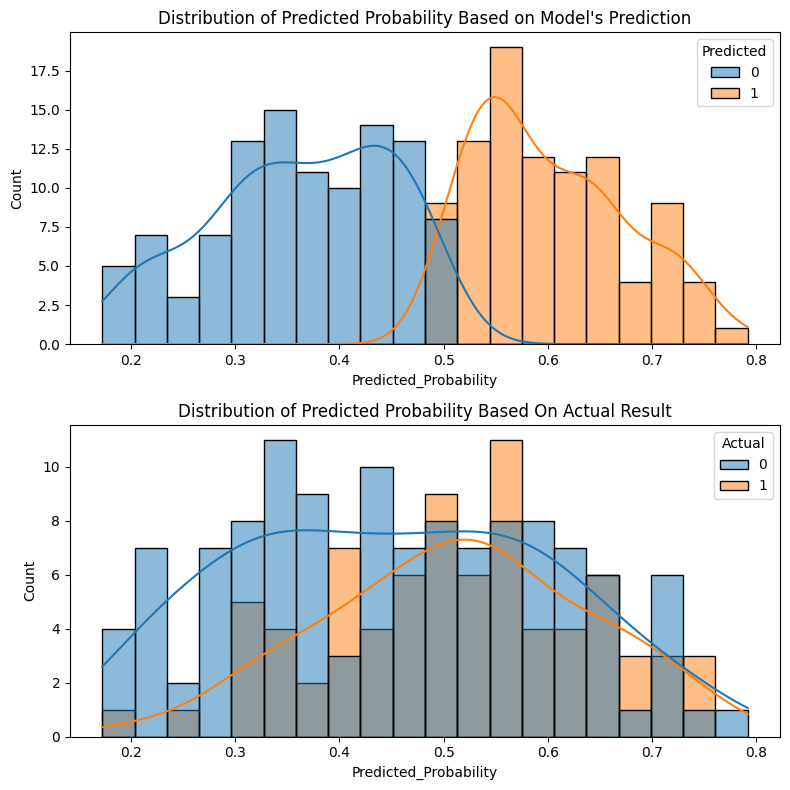

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df, kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based on Model's Prediction")
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df, kde=True, bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based On Actual Result")
plt.tight_layout()

In [0]:
lin_class_results_df['Contract_type'].value_counts()

Contract_type
Reagent Bundles            41
PCR Test Kits              34
Pipette Tips               34
Urine/Stool Sample Kits    32
Sharps Disposal            30
Blood Collection Kits      29
Name: count, dtype: int64

In [0]:
lin_class_results_df_pcr = lin_class_results_df.query("Contract_type == 'PCR Test Kits'")
lin_class_results_df_pip = lin_class_results_df.query("Contract_type == 'Pipette Tips'")
lin_class_results_df_reagent = lin_class_results_df.query("Contract_type == 'Reagent Bundles'")
lin_class_results_df_urine = lin_class_results_df.query("Contract_type == 'Urine/Stool Sample Kits'")
lin_class_results_df_sharps = lin_class_results_df.query("Contract_type == 'Sharps Disposal'")
lin_class_results_df_blood = lin_class_results_df.query("Contract_type == 'Blood Collection Kits'")

<Axes: xlabel='Predicted_Probability', ylabel='Count'>

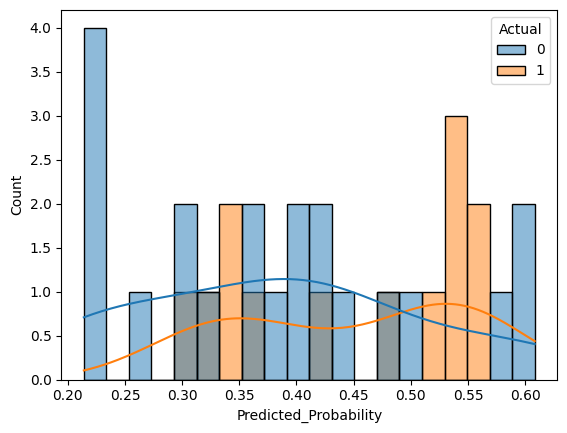

In [0]:
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_pcr, kde=True,bins=20)

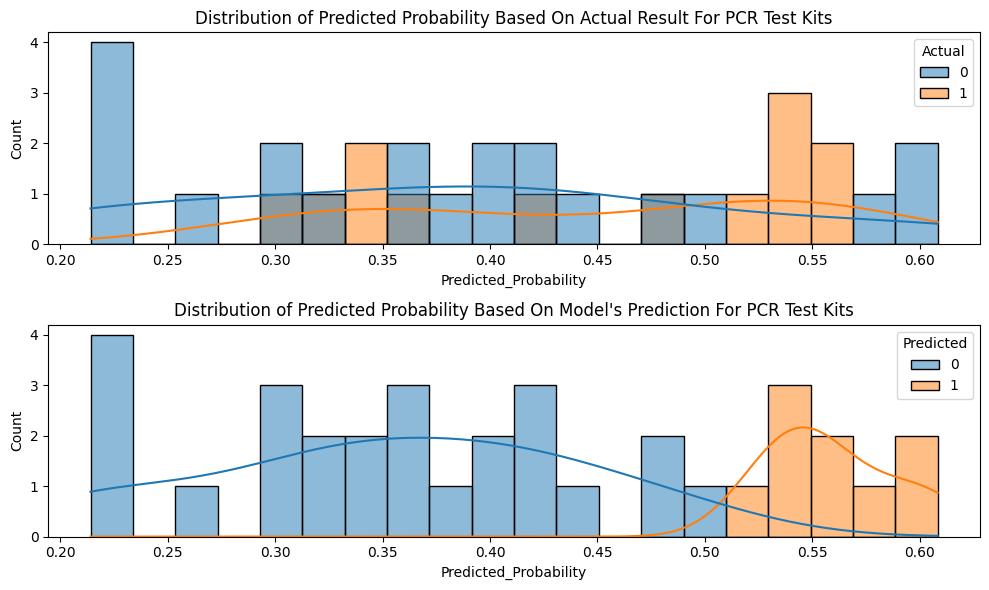

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_pcr, kde=True,bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based On Actual Result For PCR Test Kits")
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_pcr, kde=True,bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based On Model's Prediction For PCR Test Kits")
plt.tight_layout()

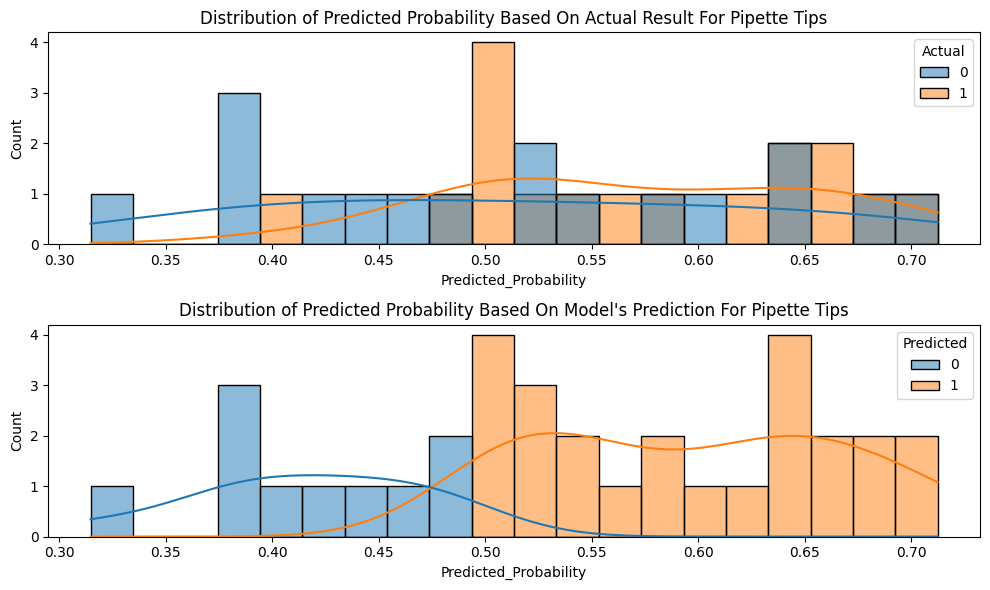

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_pip, kde=True,bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based On Actual Result For Pipette Tips")
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_pip, kde=True,bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based On Model's Prediction For Pipette Tips")
plt.tight_layout()

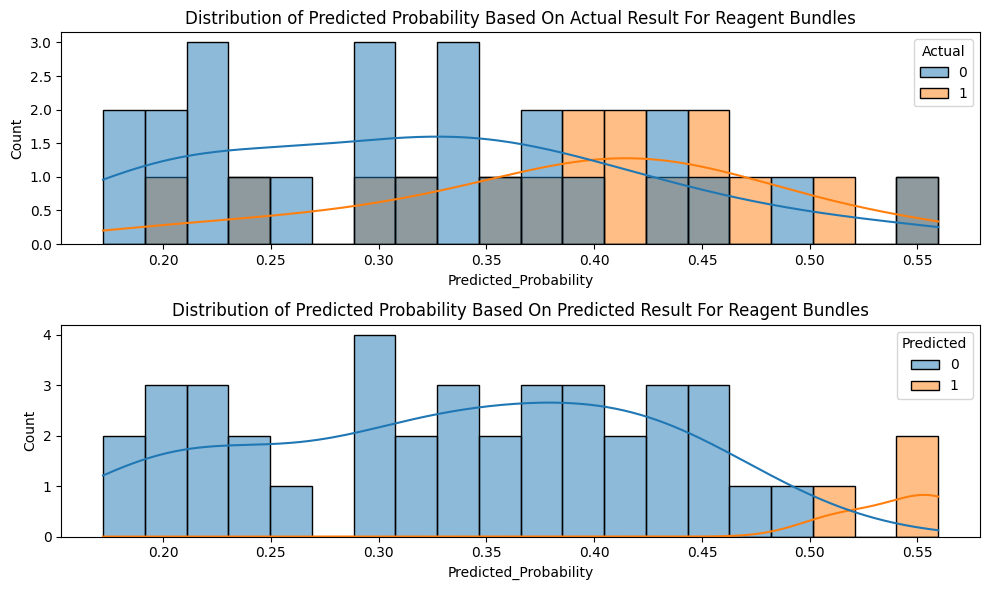

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_reagent, kde=True,bins=20, ax=axes[0])
axes[0].set_title('Distribution of Predicted Probability Based On Actual Result For Reagent Bundles')
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_reagent, kde=True,bins=20, ax=axes[1])
axes[1].set_title('Distribution of Predicted Probability Based On Predicted Result For Reagent Bundles')
plt.tight_layout()

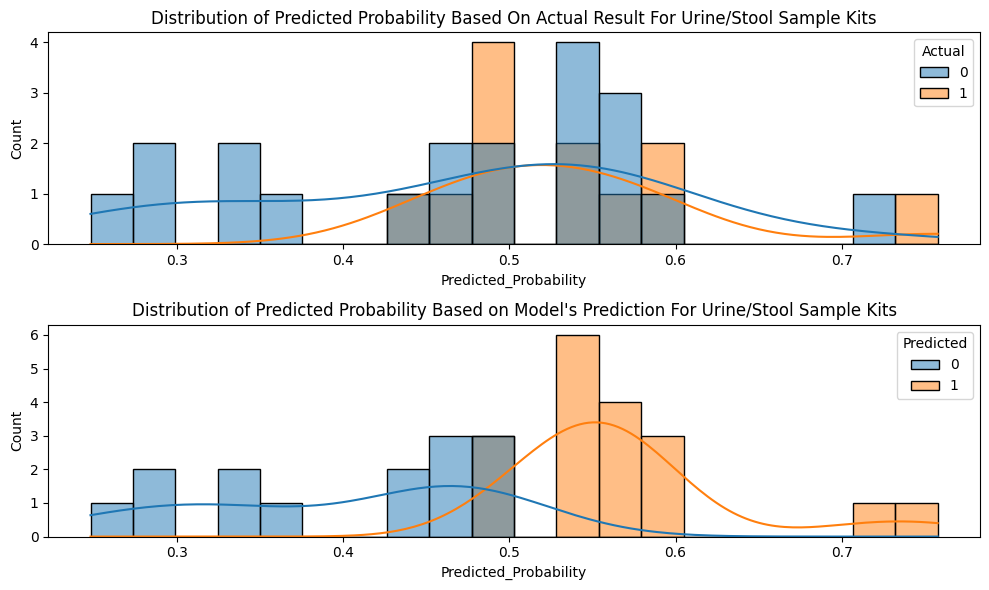

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_urine, kde=True,bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based On Actual Result For Urine/Stool Sample Kits")
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_urine, kde=True,bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based on Model's Prediction For Urine/Stool Sample Kits")
plt.tight_layout()

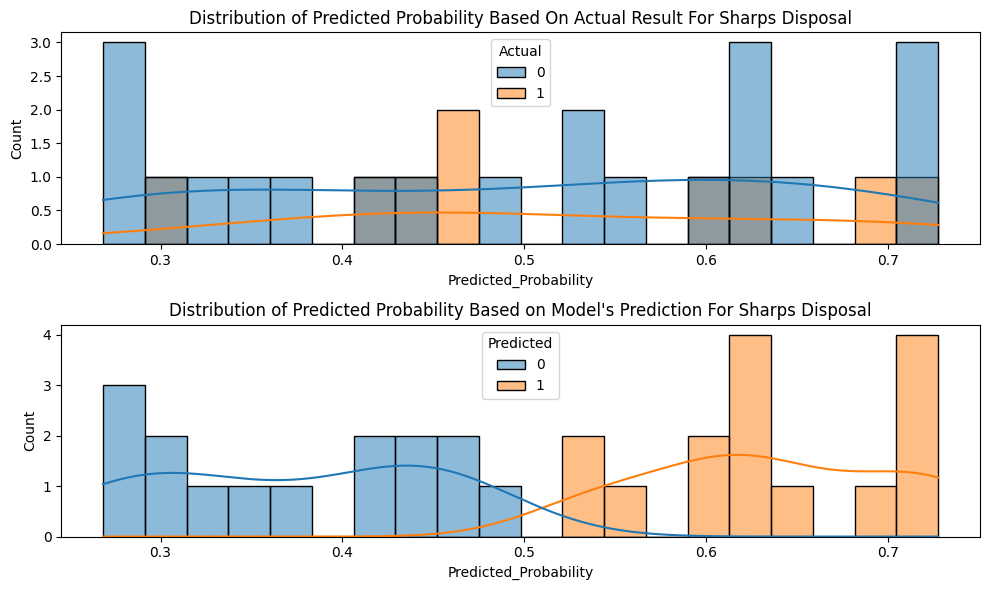

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_sharps, kde=True,bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based On Actual Result For Sharps Disposal")
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_sharps, kde=True,bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based on Model's Prediction For Sharps Disposal")
plt.tight_layout()

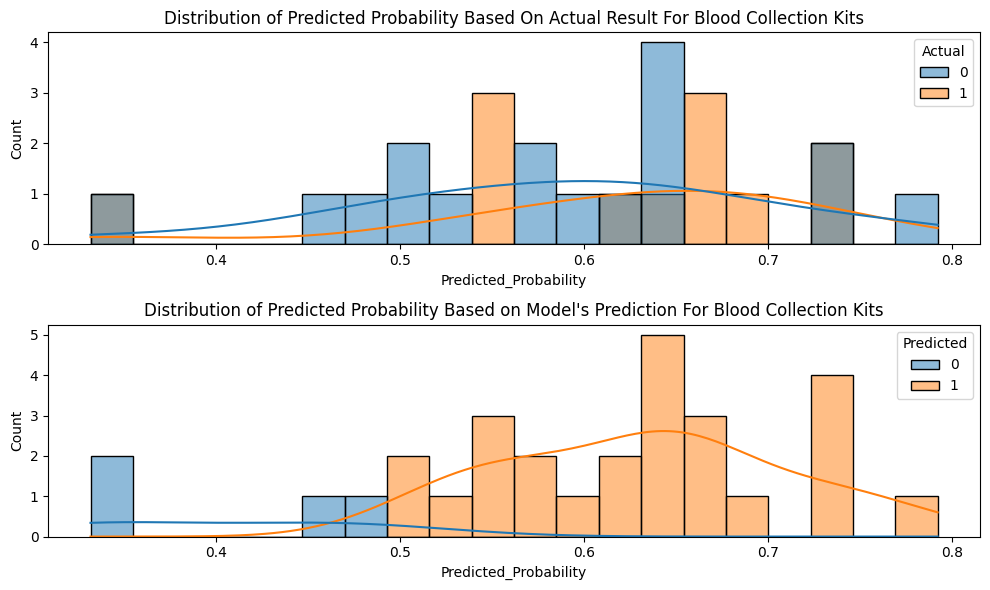

In [0]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(x='Predicted_Probability', hue='Actual', data=lin_class_results_df_blood, kde=True,bins=20, ax=axes[0])
axes[0].set_title("Distribution of Predicted Probability Based On Actual Result For Blood Collection Kits")
sns.histplot(x='Predicted_Probability', hue='Predicted', data=lin_class_results_df_blood, kde=True,bins=20, ax=axes[1])
axes[1].set_title("Distribution of Predicted Probability Based on Model's Prediction For Blood Collection Kits")
plt.tight_layout()

### Polynomial 

In [0]:
from sklearn.preprocessing import PolynomialFeatures


In [0]:
def datetime_change(df):
    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    # Encode using the classification target
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

from sklearn.preprocessing import PolynomialFeatures

def impute_scale_feats_poly(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded


def pp_poly(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats_poly(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test


def poly_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = LogisticRegression(class_weight='balanced', max_iter=500)
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    poly_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_poly_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return poly_class_results_df, overall_poly_test_results_df, model, X_train_encoded, X_test_encoded, y_train, y_test


def poly_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp_poly(df)
    return poly_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)



poly_class_results_df, overall_poly_test_results_df, poly_model, X_train_poly, X_test_poly, y_train_poly, y_test_poly = poly_pipeline(nhs_combo_df_pandas)

In [0]:
overall_poly_test_results_df

,Accuracy,Precision,Recall,F1
0,0.585,0.477778,0.544304,0.508876


### Generalised Linear Model (GLM)

In [0]:
import statsmodels.api as sm
import numpy as np

def glm_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    # Add intercept manually (statsmodels does not add it automatically)
    X_train_glm = sm.add_constant(X_train_encoded)
    X_test_glm = sm.add_constant(X_test_encoded)

    glm_binom = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
    glm_results = glm_binom.fit()

    # Predict probabilities
    y_pred_proba = glm_results.predict(X_test_glm)
    y_preds = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    glm_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_glm_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return glm_results_df, overall_glm_test_results_df, glm_results, X_train_glm, X_test_glm, y_train, y_test

def glm_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp_poly(df)
    return glm_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

glm_results_df, overall_glm_test_results_df, glm_model, X_train_glm, X_test_glm, y_train_glm, y_test_glm = glm_pipeline(nhs_combo_df_pandas)


In [0]:
glm_results_df

,Predicted,Actual,Predicted_Probability,Contract_type
754,0,0,0.299225,Reagent Bundles
768,0,1,0.469626,Urine/Stool Sample Kits
23,0,0,0.288242,Urine/Stool Sample Kits
47,0,1,0.401131,Urine/Stool Sample Kits
453,1,0,0.689313,Urine/Stool Sample Kits
...,...,...,...,...
480,0,0,0.476753,Sharps Disposal
992,0,1,0.224739,PCR Test Kits
783,0,0,0.264762,PCR Test Kits
201,0,0,0.321422,Sharps Disposal


In [0]:
overall_glm_test_results_df

,Accuracy,Precision,Recall,F1
0,0.6,0.486486,0.227848,0.310345


In [0]:
print(glm_model.summary())


                  Generalized Linear Model Regression Results                  
Dep. Variable:     bin_delivery_target   No. Observations:                  800
Model:                             GLM   Df Residuals:                      751
Model Family:                 Binomial   Df Model:                           48
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -456.79
Date:                 Fri, 06 Mar 2026   Deviance:                       913.58
Time:                         18:17:48   Pearson chi2:                     774.
No. Iterations:                    100   Pseudo R-squ. (CS):             0.1444
Covariance Type:             nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### Bayesian

In [0]:
import statsmodels.api as sm

def datetime_change(df):
    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

from sklearn.preprocessing import PolynomialFeatures

def impute_scale_feats_poly(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

def pp_poly(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats_poly(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test


def bayes_glm_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    X_train_glm = sm.add_constant(X_train_encoded)
    X_test_glm = sm.add_constant(X_test_encoded)

    # Bayesian GLM via regularization (Laplace prior = L1_wt=1)
    bayes_glm = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())

    bayes_results = bayes_glm.fit_regularized(
        method="elastic_net",
        alpha=0.1,        # strength of prior
        L1_wt=1.0         # 1.0 = pure L1 (Laplace prior)
    )

    y_pred_proba = bayes_results.predict(X_test_glm)
    y_preds = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    bayes_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_bayes_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return bayes_results_df, overall_bayes_test_results_df, bayes_results, X_train_glm, X_test_glm, y_train, y_test


def bayes_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp_poly(df)
    return bayes_glm_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

bayes_results_df, overall_bayes_test_results_df, bayes_model, X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = bayes_pipeline(nhs_combo_df_pandas)


/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [0]:
overall_bayes_test_results_df

,Accuracy,Precision,Recall,F1
0,0.605,0.0,0.0,0.0


### Linear Overall Results

In [0]:
overall_lin_test_results_df["Model"] = "Linear"
overall_bayes_test_results_df["Model"] = "Bayesian"
overall_glm_test_results_df["Model"] = "GLM"
overall_poly_test_results_df["Model"] = "Polynomial"
overall_rfc_test_results_df["Model"] = "RandomForest"


In [0]:
all_results = pd.concat([overall_lin_test_results_df, overall_bayes_test_results_df, overall_glm_test_results_df, overall_poly_test_results_df, overall_rfc_test_results_df], axis=0)

In [0]:
all_results

,Accuracy,Precision,Recall,F1,Model
0,0.605,0.500000,0.594937,0.543353,Linear
0,0.605,0.000000,0.000000,0.000000,Bayesian
0,0.600,0.486486,0.227848,0.310345,GLM
0,0.585,0.477778,0.544304,0.508876,Polynomial
0,0.580,0.428571,0.189873,0.263158,RandomForest


In [0]:
lin_class_results_df[:1]

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.235207,Reagent Bundles


In [0]:
bayes_results_df[:1]

,Predicted,Actual,Predicted_Probability,Contract_type
754,0,0,0.4525,Reagent Bundles


In [0]:
rf_class_results_df[:1]

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.22,Reagent Bundles


In [0]:
lin_class_results_df.head(3)

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.235207,Reagent Bundles
1,1,1,0.548408,Urine/Stool Sample Kits
2,0,0,0.449092,Urine/Stool Sample Kits


In [0]:
bayes_results_df.head(3)

,Predicted,Actual,Predicted_Probability,Contract_type
754,0,0,0.4525,Reagent Bundles
768,0,1,0.4525,Urine/Stool Sample Kits
23,0,0,0.4525,Urine/Stool Sample Kits


In [0]:
rfc_class_results_df.head(3)

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.178388,Reagent Bundles
1,0,1,0.499789,Urine/Stool Sample Kits
2,0,0,0.487868,Urine/Stool Sample Kits


In [0]:
glm_results_df.head(3)

,Predicted,Actual,Predicted_Probability,Contract_type
754,0,0,0.299225,Reagent Bundles
768,0,1,0.469626,Urine/Stool Sample Kits
23,0,0,0.288242,Urine/Stool Sample Kits


In [0]:
lin_class_results_df['Model'] = 'Linear'
bayes_results_df['Model'] = 'Bayesian'
rfc_class_results_df['Model'] = 'RandomForest'
glm_results_df['Model'] = 'GLM'
poly_class_results_df['Model'] = 'Polynomial'

In [0]:
individual_results_df = pd.concat([lin_class_results_df, bayes_results_df, rfc_class_results_df, glm_results_df], axis=0)
individual_results_df


,Predicted,Actual,Predicted_Probability,Contract_type,Model
0,0,0,0.235207,Reagent Bundles,Linear
1,1,1,0.548408,Urine/Stool Sample Kits,Linear
2,0,0,0.449092,Urine/Stool Sample Kits,Linear
3,1,1,0.500252,Urine/Stool Sample Kits,Linear
4,1,0,0.711863,Urine/Stool Sample Kits,Linear
...,...,...,...,...,...
480,0,0,0.476753,Sharps Disposal,GLM
992,0,1,0.224739,PCR Test Kits,GLM
783,0,0,0.264762,PCR Test Kits,GLM
201,0,0,0.321422,Sharps Disposal,GLM


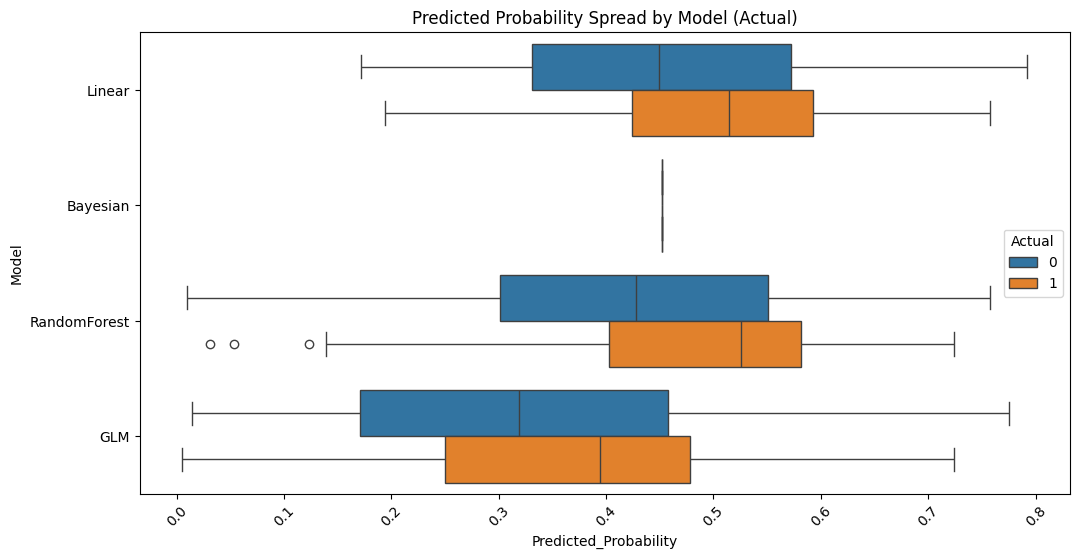

In [0]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=individual_results_df,
    y="Model",
    x="Predicted_Probability",
    hue="Actual"
)
plt.title("Predicted Probability Spread by Model (Actual)")
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='Model', ylabel='Accuracy'>

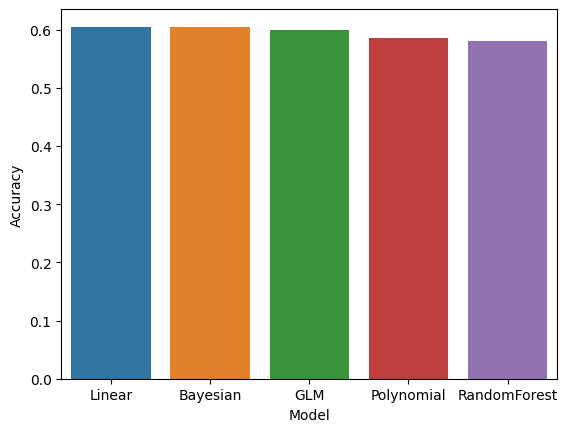

In [0]:
sns.barplot(x='Model', y='Accuracy', hue='Model',data=all_results)

### Rfr Model

In [0]:
def datetime_change(df):
    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    # Encode using the classification target
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

def pp(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

def rf_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    rf_model = RandomForestClassifier(n_estimators=150, class_weight='balanced')
    rf_model.fit(X_train_encoded, y_train)

    y_preds = rf_model.predict(X_test_encoded)
    y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1] # probability of delivering on time (1)

    # Classification metrics
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    rf_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_rfc_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return rf_class_results_df, overall_rfc_test_results_df, rf_model, X_train_encoded, X_test_encoded, y_train, y_test


def rfc_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return rf_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

rf_class_results_df, overall_rfc_test_results_df, rf_model, X_train_encoded, X_test_encoded, y_train, y_test = rfc_pipeline(nhs_combo_df_pandas)



In [0]:
rfc_class_results_df.sample(4)

,Predicted,Actual,Predicted_Probability,Contract_type
142,0,0,0.083635,Reagent Bundles
78,1,0,0.573860,Sharps Disposal
104,1,0,0.516415,Pipette Tips
36,0,0,0.498116,Blood Collection Kits


In [0]:
overall_rfc_test_results_df

,Accuracy,Precision,Recall,F1
0,0.58,0.428571,0.189873,0.263158


In [0]:
import shap

# Create SHAP explainer for logistic regression
explainer = shap.Explainer(rf_model, X_train_encoded)

# Compute SHAP values for the test set
shap_values = explainer(X_test_encoded)

# Waterfall plot for the first prediction
shap.plots.waterfall(shap_values[0])


---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-7091656961899301>, line 10
      7 shap_values = explainer(X_test_encoded)
      9 # Waterfall plot for the first prediction
---> 10 shap.plots.waterfall(shap_values[0])

File /local_disk0/.ephemeral_nfs/envs/pythonEnv-d87f34ae-a359-47fa-b147-0ca4aac2229d/lib/python3.12/site-packages/shap/plots/_waterfall.py:65, in waterfall(shap_values, max_display, show)
     58 if len(sv_shape) != 1:
     59     emsg = (
     60         "The waterfall plot can currently only plot a single explanation, but a "
     61         f"matrix of explanations (shape {sv_shape}) was passed! Perhaps try "
     62         "`shap.plots.waterfall(shap_values[0])` or for multi-output models, "
     63         "try `shap.plots.waterfall(shap_values[0, 0])`."
     64     )
---> 65     raise ValueError(emsg)
     67 base_values = float(shap_values.base_va

### PCA Linear Classification

In [0]:
from sklearn.decomposition import PCA
def datetime_change(df):

    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    # Encode using the classification target
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

def pp(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

def lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = LogisticRegression(class_weight='balanced')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1] # probability of delivering on time (1)

    # Classification metrics
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    lin_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_lin_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return lin_class_results_df, overall_lin_test_results_df

def lin_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

lin_class_results_df, overall_lin_test_results_df = lin_pipeline(nhs_combo_df_pandas)


In [0]:
overall_lin_test_results_df

,Accuracy,Precision,Recall,F1
0,0.595,0.489583,0.594937,0.537143


### PCA RF Classification

In [0]:
def datetime_change(df):
    nhs_combo_df_pandas['issue_date'] = pd.to_datetime(nhs_combo_df_pandas['issue_date'], errors='coerce')
    nhs_combo_df_pandas['closing_date'] = pd.to_datetime(nhs_combo_df_pandas['closing_date'], errors='coerce')
    nhs_combo_df_pandas['delivery_date'] = pd.to_datetime(nhs_combo_df_pandas['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    nhs_combo_df_pandas['qc_per_unit'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quantity']

def bin_delivery_target(row):
    return 1 if row['quoted_lead_days'] == row['actual_lead_days'] else 0

def assign_month(df):
    nhs_combo_df_pandas['closing_date_month'] = nhs_combo_df_pandas['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    nhs_combo_df_pandas['qc_per_day'] = nhs_combo_df_pandas['quoted_cost'] / nhs_combo_df_pandas['quoted_lead_days']

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_delivery_target']

    X = nhs_combo_df_pandas[cat_feat + num_feat]
    y = nhs_combo_df_pandas['bin_delivery_target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    return X_train, X_test, y_train, y_test, X_test['contract_type']

def target_encode_cols(X_train, X_test):
    # Encode using the classification target
    season_means = X_train.groupby('closing_date_season')['bin_delivery_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    contract_means = X_train.groupby('contract_type')['bin_delivery_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    postcode_means = X_train.groupby('postcode')['bin_delivery_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    month_means = X_train.groupby('closing_date_month')['bin_delivery_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    X_train = X_train.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])
    X_test = X_test.drop(columns=['postcode', 'contract_type', 'closing_date_month', 'bin_delivery_target'])

    return X_train, X_test

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
                'season_encoded', 'contract_encoded', 'postcode_encoded', 'month_encoded']

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

def pp(df):
    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    nhs_combo_df_pandas['closing_date_season'] = nhs_combo_df_pandas['closing_date_month'].apply(assign_season)
    nhs_combo_df_pandas['bin_delivery_target'] = nhs_combo_df_pandas.apply(bin_delivery_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

def rfc_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=27, class_weight='balanced_subsample')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1] # probability of delivering on time (1)

    # Classification metrics
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    rfc_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_rfc_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return rfc_class_results_df, overall_rfc_test_results_df

def rfc_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return rfc_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

rfc_class_results_df, overall_rfc_test_results_df = rfc_pipeline(nhs_combo_df_pandas)


In [0]:
overall_rfc_test_results_df

,Accuracy,Precision,Recall,F1
0,0.605,0.5,0.582278,0.538012


### Voting Classification

In [0]:
def voting_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    # Base models
    lin_model = LogisticRegression(max_iter=500)
    knn_model = KNeighborsClassifier(n_neighbors=8)
    rfc_model = RandomForestClassifier(n_estimators=100)
    gbc_model = GradientBoostingClassifier(n_estimators=100)

    # Voting classifier (soft voting recommended for probabilities)
    voting_model = VotingClassifier(
        estimators=[
            ('lin', lin_model),
            ('knn', knn_model),
            ('rfc', rfc_model),
            ('gbc', gbc_model)
        ],
        voting='soft'
    )

    # Fit
    voting_model.fit(X_train_encoded, y_train)

    # Predictions
    y_preds = voting_model.predict(X_test_encoded)
    #y_pred_proba = LogisticRegression.predict_proba(X_test_encoded)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    # Row‑level results
    voting_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        #"Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    # Summary metrics
    overall_voting_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return voting_class_results_df, overall_voting_test_results_df


def voting_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return voting_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

voting_class_results_df, overall_voting_test_results_df = voting_pipeline(nhs_combo_df_pandas)



In [0]:
voting_class_results_df.sample(4)

,Predicted,Actual,Predicted_Probability,Contract_type
129,0,0,0.214467,PCR Test Kits
93,0,1,0.354466,Pipette Tips
114,0,1,0.387290,PCR Test Kits
173,0,1,0.220731,PCR Test Kits


In [0]:
overall_voting_test_results_df

,Accuracy,Precision,Recall,F1
0,0.61,0.516129,0.202532,0.290909


## Classification of Price

### Logistic Regression

In [0]:
# ---------------------------------------------------------
# 1. PREPROCESSING HELPERS
# ---------------------------------------------------------

def datetime_change(df):
    df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
    df['closing_date'] = pd.to_datetime(df['closing_date'], errors='coerce')
    df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    df['qc_per_unit'] = df['quoted_cost'] / df['quantity']

def bin_cost_target(row):
    return 1 if row['quoted_cost'] == row['actual_cost'] else 0

def assign_month(df):
    df['closing_date_month'] = df['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    df['qc_per_day'] = df['quoted_cost'] / df['quoted_lead_days']

# ---------------------------------------------------------
# 2. TRAIN/TEST SPLIT
# ---------------------------------------------------------

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_cost_target', 'actual_cost']

    X = df[cat_feat + num_feat]
    y = df['bin_cost_target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=27
    )

    return X_train, X_test, y_train, y_test, X_test['contract_type']

# ---------------------------------------------------------
# 3. TARGET ENCODING
# ---------------------------------------------------------

def target_encode_cols(X_train, X_test):

    # season → mean target
    season_means = X_train.groupby('closing_date_season')['bin_cost_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    # (season, contract_type) → mean actual cost
    season_contract_cost_means = (
        X_train.groupby(['closing_date_season', 'contract_type','quantity'])['actual_cost'].mean()
    )

    X_train['season_con_cost_encoded'] = X_train.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'], r['quantity']), np.nan),
        axis=1
    )
    X_test['season_con_cost_encoded'] = X_test.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'],r['quantity']), np.nan),
        axis=1
    )

    # contract → mean target
    contract_means = X_train.groupby('contract_type')['bin_cost_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    # postcode → mean target
    postcode_means = X_train.groupby('postcode')['bin_cost_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    # month → mean target
    month_means = X_train.groupby('closing_date_month')['bin_cost_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    drop_cols = ['postcode', 'contract_type', 'closing_date_month', 'bin_cost_target', 'actual_cost']
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    return X_train, X_test

# ---------------------------------------------------------
# 4. IMPUTE + SCALE
# ---------------------------------------------------------

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = [
        'quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
        'season_encoded', 'contract_encoded', 'postcode_encoded',
        'month_encoded', 'season_con_cost_encoded'
    ]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

# ---------------------------------------------------------
# 5. FULL PREPROCESSING PIPELINE
# ---------------------------------------------------------

def pp(df):
    df = df.copy()

    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    df['closing_date_season'] = df['closing_date_month'].apply(assign_season)
    df['bin_cost_target'] = df.apply(bin_cost_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

# ---------------------------------------------------------
# 6. LOGISTIC MODEL
# ---------------------------------------------------------

def lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = LogisticRegression(class_weight='balanced')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    lin_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_lin_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return lin_class_results_df, overall_lin_test_results_df

def lin_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return lin_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

# ---------------------------------------------------------
# 7. RUN PIPELINE
# ---------------------------------------------------------

lin_class_results_df, overall_lin_test_results_df = lin_pipeline(nhs_combo_df_pandas)


In [0]:
lin_class_results_df.sample(5)

,Predicted,Actual,Predicted_Probability,Contract_type
150,0,0,0.411430,Pipette Tips
122,0,0,0.440198,PCR Test Kits
76,1,0,0.740931,Pipette Tips
137,0,1,0.409609,Reagent Bundles
7,1,1,0.585632,Pipette Tips


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Reagent Bundles'),
  Text(1, 0, 'Urine/Stool Sample Kits'),
  Text(2, 0, 'Sharps Disposal'),
  Text(3, 0, 'PCR Test Kits'),
  Text(4, 0, 'Pipette Tips'),
  Text(5, 0, 'Blood Collection Kits')])

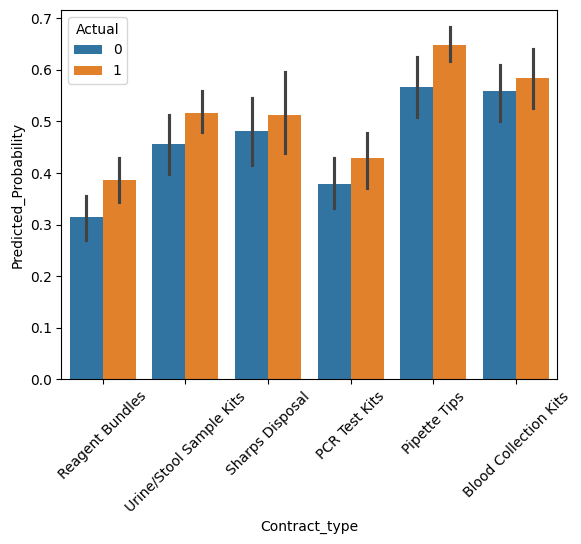

In [0]:
sns.barplot(x='Contract_type', y='Predicted_Probability', hue='Actual', data=lin_class_results_df)
plt.xticks(rotation=45)

(array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]),
 [Text(0.1, 0, '0.1'),
  Text(0.2, 0, '0.2'),
  Text(0.30000000000000004, 0, '0.3'),
  Text(0.4, 0, '0.4'),
  Text(0.5, 0, '0.5'),
  Text(0.6, 0, '0.6'),
  Text(0.7000000000000001, 0, '0.7'),
  Text(0.8, 0, '0.8')])

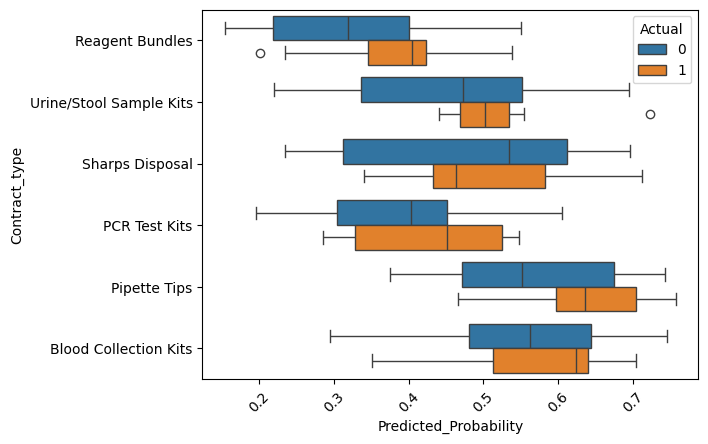

In [0]:
sns.boxplot(x='Predicted_Probability', y='Contract_type', hue='Actual', data=lin_class_results_df)
plt.xticks(rotation=45)

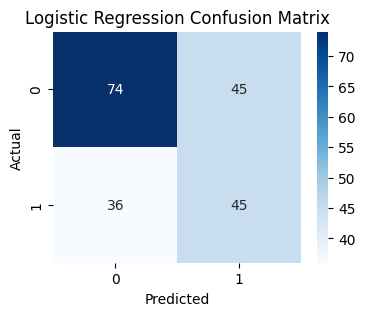

In [0]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(lin_class_results_df["Actual"], lin_class_results_df["Predicted"])

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [0]:
overall_lin_test_results_df

,Accuracy,Precision,Recall,F1
0,0.595,0.5,0.555556,0.526316


In [0]:
p = lin_class_results_df.loc[0, "Predicted_Probability"]


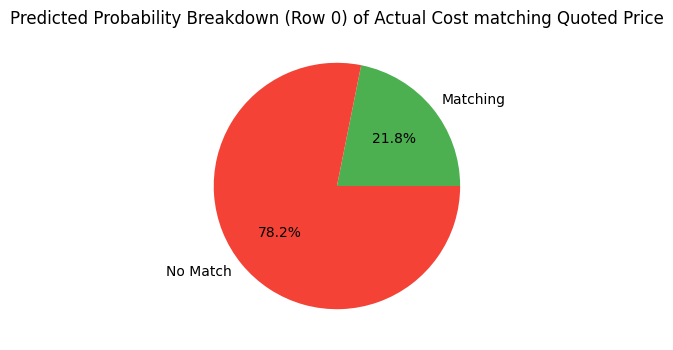

In [0]:
plt.figure(figsize=(4,4))
plt.pie(
    [p, 1-p],
    labels=["Matching", "No Match"],
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"]
)
plt.title("Predicted Probability Breakdown (Row 0) of Actual Cost matching Quoted Price")
plt.show()


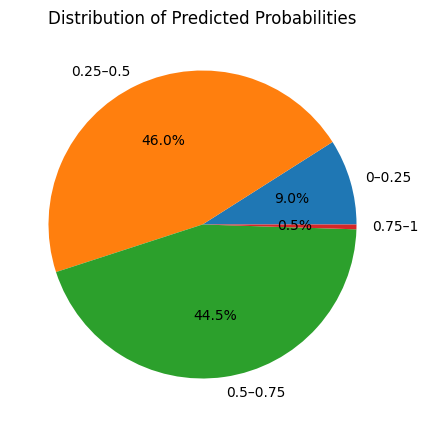

In [0]:
bins = [0, 0.25, 0.5, 0.75, 1]
labels = ["0–0.25", "0.25–0.5", "0.5–0.75", "0.75–1"]

lin_class_results_df["prob_bin"] = pd.cut(
    lin_class_results_df["Predicted_Probability"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

prob_counts = lin_class_results_df["prob_bin"].value_counts().sort_index()

plt.figure(figsize=(5,5))
plt.pie(prob_counts, labels=prob_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Predicted Probabilities")
plt.show()


### Rfc

In [0]:
# ---------------------------------------------------------
# 1. PREPROCESSING HELPERS
# ---------------------------------------------------------

def datetime_change(df):
    df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
    df['closing_date'] = pd.to_datetime(df['closing_date'], errors='coerce')
    df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    df['qc_per_unit'] = df['quoted_cost'] / df['quantity']

def bin_cost_target(row):
    return 1 if row['quoted_cost'] == row['actual_cost'] else 0

def assign_month(df):
    df['closing_date_month'] = df['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    df['qc_per_day'] = df['quoted_cost'] / df['quoted_lead_days']

# ---------------------------------------------------------
# 2. TRAIN/TEST SPLIT
# ---------------------------------------------------------

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_cost_target', 'actual_cost']

    X = df[cat_feat + num_feat]
    y = df['bin_cost_target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=27
    )

    return X_train, X_test, y_train, y_test, X_test['contract_type']

# ---------------------------------------------------------
# 3. TARGET ENCODING
# ---------------------------------------------------------

def target_encode_cols(X_train, X_test):

    # season → mean target
    season_means = X_train.groupby('closing_date_season')['bin_cost_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    # (season, contract_type) → mean actual cost
    season_contract_cost_means = (
        X_train.groupby(['closing_date_season', 'contract_type','quantity'])['actual_cost'].mean()
    )

    X_train['season_con_cost_encoded'] = X_train.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'], r['quantity']), np.nan),
        axis=1
    )
    X_test['season_con_cost_encoded'] = X_test.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'],r['quantity']), np.nan),
        axis=1
    )

    # contract → mean target
    contract_means = X_train.groupby('contract_type')['bin_cost_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    # postcode → mean target
    postcode_means = X_train.groupby('postcode')['bin_cost_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    # month → mean target
    month_means = X_train.groupby('closing_date_month')['bin_cost_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    drop_cols = ['postcode', 'contract_type', 'closing_date_month', 'bin_cost_target', 'actual_cost']
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    return X_train, X_test

# ---------------------------------------------------------
# 4. IMPUTE + SCALE
# ---------------------------------------------------------

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = [
        'quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
        'season_encoded', 'contract_encoded', 'postcode_encoded',
        'month_encoded', 'season_con_cost_encoded'
    ]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

# ---------------------------------------------------------
# 5. FULL PREPROCESSING PIPELINE
# ---------------------------------------------------------

def pp(df):
    df = df.copy()

    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    df['closing_date_season'] = df['closing_date_month'].apply(assign_season)
    df['bin_cost_target'] = df.apply(bin_cost_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

# ---------------------------------------------------------
# 6. LOGISTIC MODEL
# ---------------------------------------------------------

def rf_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=27, class_weight='balanced_subsample')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    rf_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_rfc_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return rf_class_results_df, overall_rfc_test_results_df

def rfc_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return rf_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

# ---------------------------------------------------------
# 7. RUN PIPELINE
# ---------------------------------------------------------

rf_class_results_df, overall_rfc_test_results_df = rfc_pipeline(nhs_combo_df_pandas)


In [0]:
rf_class_results_df.sample(4)

,Predicted,Actual,Predicted_Probability,Contract_type
147,1,0,0.551807,Urine/Stool Sample Kits
171,1,1,0.610751,Pipette Tips
156,0,1,0.433945,PCR Test Kits
161,0,0,0.480332,Urine/Stool Sample Kits


In [0]:
overall_rfc_test_results_df

,Accuracy,Precision,Recall,F1
0,0.615,0.525641,0.506173,0.515723


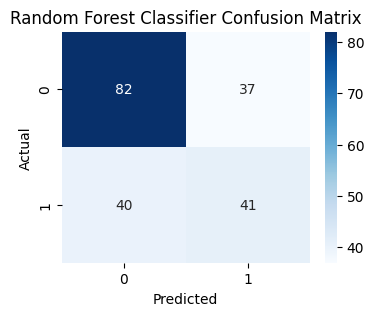

In [0]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(rf_class_results_df["Actual"], rf_class_results_df["Predicted"])

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [0]:
p_rf = rf_class_results_df.loc[0, "Predicted_Probability"]


In [0]:
rf_class_results_df[0:1]

,Predicted,Actual,Predicted_Probability,Contract_type
0,0,0,0.31564,Reagent Bundles


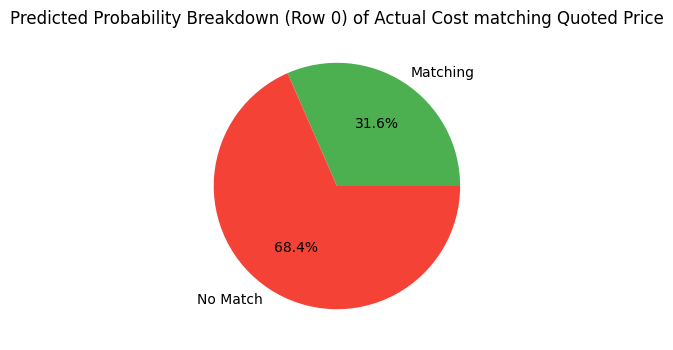

In [0]:
plt.figure(figsize=(4,4))
plt.pie(
    [p_rf, 1-p_rf],
    labels=["Matching", "No Match"],
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"]
)
plt.title("Predicted Probability Breakdown (Row 0) of Actual Cost matching Quoted Price")
plt.show()


### xgboost

In [0]:
!pip install xgboost

from xgboost import XGBClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.7/289.7 MB 93.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

# ---------------------------------------------------------
# 1. PREPROCESSING HELPERS
# ---------------------------------------------------------

def datetime_change(df):
    df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
    df['closing_date'] = pd.to_datetime(df['closing_date'], errors='coerce')
    df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    df['qc_per_unit'] = df['quoted_cost'] / df['quantity']

def bin_cost_target(row):
    return 1 if row['quoted_cost'] == row['actual_cost'] else 0

def assign_month(df):
    df['closing_date_month'] = df['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    df['qc_per_day'] = df['quoted_cost'] / df['quoted_lead_days']

# ---------------------------------------------------------
# 2. TRAIN/TEST SPLIT
# ---------------------------------------------------------

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_cost_target', 'actual_cost']

    X = df[cat_feat + num_feat]
    y = df['bin_cost_target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=27
    )

    return X_train, X_test, y_train, y_test, X_test['contract_type']

# ---------------------------------------------------------
# 3. TARGET ENCODING
# ---------------------------------------------------------

def target_encode_cols(X_train, X_test):

    # season → mean target
    season_means = X_train.groupby('closing_date_season')['bin_cost_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    # (season, contract_type) → mean actual cost
    season_contract_cost_means = (
        X_train.groupby(['closing_date_season', 'contract_type','quantity'])['actual_cost'].mean()
    )

    X_train['season_con_cost_encoded'] = X_train.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'], r['quantity']), np.nan),
        axis=1
    )
    X_test['season_con_cost_encoded'] = X_test.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'],r['quantity']), np.nan),
        axis=1
    )

    # contract → mean target
    contract_means = X_train.groupby('contract_type')['bin_cost_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    # postcode → mean target
    postcode_means = X_train.groupby('postcode')['bin_cost_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    # month → mean target
    month_means = X_train.groupby('closing_date_month')['bin_cost_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    drop_cols = ['postcode', 'contract_type', 'closing_date_month', 'bin_cost_target', 'actual_cost']
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    return X_train, X_test

# ---------------------------------------------------------
# 4. IMPUTE + SCALE
# ---------------------------------------------------------

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = [
        'quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
        'season_encoded', 'contract_encoded', 'postcode_encoded',
        'month_encoded', 'season_con_cost_encoded'
    ]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

# ---------------------------------------------------------
# 5. FULL PREPROCESSING PIPELINE
# ---------------------------------------------------------

def pp(df):
    df = df.copy()

    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    df['closing_date_season'] = df['closing_date_month'].apply(assign_season)
    df['bin_cost_target'] = df.apply(bin_cost_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

# ---------------------------------------------------------
# 6. LOGISTIC MODEL
# ---------------------------------------------------------

def xgboost_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = XGBClassifier( n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss')
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    xgboost_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_xgboost_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return xgboost_class_results_df, overall_xgboost_test_results_df

def xgboost_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return xgboost_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

# ---------------------------------------------------------
# 7. RUN PIPELINE
# ---------------------------------------------------------

xgboost_class_results_df, overall_xgboost_test_results_df = xgboost_pipeline(nhs_combo_df_pandas)


In [0]:
xgboost_class_results_df.sample(4)

,Predicted,Actual,Predicted_Probability,Contract_type
10,0,0,0.115730,PCR Test Kits
188,0,1,0.374809,PCR Test Kits
42,1,0,0.582504,Pipette Tips
68,0,0,0.434092,Urine/Stool Sample Kits


In [0]:
overall_xgboost_test_results_df

,Accuracy,Precision,Recall,F1
0,0.595,0.5,0.37037,0.425532


### knnClass

In [0]:

# ---------------------------------------------------------
# 1. PREPROCESSING HELPERS
# ---------------------------------------------------------

def datetime_change(df):
    df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
    df['closing_date'] = pd.to_datetime(df['closing_date'], errors='coerce')
    df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

def calc_qp_per_unit(df):
    df['qc_per_unit'] = df['quoted_cost'] / df['quantity']

def bin_cost_target(row):
    return 1 if row['quoted_cost'] == row['actual_cost'] else 0

def assign_month(df):
    df['closing_date_month'] = df['closing_date'].dt.month_name()

def assign_season(month):
    if month in ("March", "April", "May"):
        return "Spring"
    elif month in ("June", "July", "August"):
        return "Summer"
    elif month in ("September", "October", "November"):
        return "Autumn"
    else:
        return "Winter"

def calc_qc_per_day(df):
    df['qc_per_day'] = df['quoted_cost'] / df['quoted_lead_days']

# ---------------------------------------------------------
# 2. TRAIN/TEST SPLIT
# ---------------------------------------------------------

def seperate_train_test(df):
    cat_feat = ['contract_type', 'postcode', 'closing_date_season', 'closing_date_month', 'supplier_name']
    num_feat = ['quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day', 'bin_cost_target', 'actual_cost']

    X = df[cat_feat + num_feat]
    y = df['bin_cost_target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=27
    )

    return X_train, X_test, y_train, y_test, X_test['contract_type']

# ---------------------------------------------------------
# 3. TARGET ENCODING
# ---------------------------------------------------------

def target_encode_cols(X_train, X_test):

    # season → mean target
    season_means = X_train.groupby('closing_date_season')['bin_cost_target'].mean()
    X_train['season_encoded'] = X_train['closing_date_season'].map(season_means)
    X_test['season_encoded'] = X_test['closing_date_season'].map(season_means)

    # (season, contract_type) → mean actual cost
    season_contract_cost_means = (
        X_train.groupby(['closing_date_season', 'contract_type','quantity'])['actual_cost'].mean()
    )

    X_train['season_con_cost_encoded'] = X_train.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'], r['quantity']), np.nan),
        axis=1
    )
    X_test['season_con_cost_encoded'] = X_test.apply(
        lambda r: season_contract_cost_means.get((r['closing_date_season'], r['contract_type'],r['quantity']), np.nan),
        axis=1
    )

    # contract → mean target
    contract_means = X_train.groupby('contract_type')['bin_cost_target'].mean()
    X_train['contract_encoded'] = X_train['contract_type'].map(contract_means)
    X_test['contract_encoded'] = X_test['contract_type'].map(contract_means)

    # postcode → mean target
    postcode_means = X_train.groupby('postcode')['bin_cost_target'].mean()
    X_train['postcode_encoded'] = X_train['postcode'].map(postcode_means)
    X_test['postcode_encoded'] = X_test['postcode'].map(postcode_means)

    # month → mean target
    month_means = X_train.groupby('closing_date_month')['bin_cost_target'].mean()
    X_train['month_encoded'] = X_train['closing_date_month'].map(month_means)
    X_test['month_encoded'] = X_test['closing_date_month'].map(month_means)

    # Drop original columns
    drop_cols = ['postcode', 'contract_type', 'closing_date_month', 'bin_cost_target', 'actual_cost']
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    return X_train, X_test

# ---------------------------------------------------------
# 4. IMPUTE + SCALE
# ---------------------------------------------------------

def impute_scale_feats(X_train, X_test):
    cat_feat = ['closing_date_season', 'supplier_name']
    num_feat = [
        'quantity', 'qc_per_unit', 'quoted_cost', 'qc_per_day',
        'season_encoded', 'contract_encoded', 'postcode_encoded',
        'month_encoded', 'season_con_cost_encoded'
    ]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, cat_feat),
            ("num", numerical_transformer, num_feat)
        ]
    )

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return X_train_encoded, X_test_encoded

# ---------------------------------------------------------
# 5. FULL PREPROCESSING PIPELINE
# ---------------------------------------------------------

def pp(df):
    df = df.copy()

    datetime_change(df)
    calc_qp_per_unit(df)
    assign_month(df)
    df['closing_date_season'] = df['closing_date_month'].apply(assign_season)
    df['bin_cost_target'] = df.apply(bin_cost_target, axis=1)
    calc_qc_per_day(df)

    X_train, X_test, y_train, y_test, contract_type_test = seperate_train_test(df)
    X_train, X_test = target_encode_cols(X_train, X_test)
    X_train_encoded, X_test_encoded = impute_scale_feats(X_train, X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test

# ---------------------------------------------------------
# 6. LOGISTIC MODEL
# ---------------------------------------------------------

def knn_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    model = KNeighborsClassifier(n_neighbors=13)
    model.fit(X_train_encoded, y_train)

    y_preds = model.predict(X_test_encoded)
    y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    recall = recall_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    knn_class_results_df = pd.DataFrame({
        "Predicted": y_preds,
        "Actual": y_test.values,
        "Predicted_Probability": y_pred_proba,
        "Contract_type": contract_type_test.values
    })

    overall_knnc_test_results_df = pd.DataFrame([{
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }])

    return knn_class_results_df, overall_knnc_test_results_df

def knnc_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return knn_class_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)

# ---------------------------------------------------------
# 7. RUN PIPELINE
# ---------------------------------------------------------

knn_class_results_df, overall_knnc_test_results_df = knnc_pipeline(nhs_combo_df_pandas)


In [0]:
knn_class_results_df.sample(4)

,Predicted,Actual,Predicted_Probability,Contract_type
88,0,1,0.285714,Pipette Tips
193,0,0,0.285714,Urine/Stool Sample Kits
105,1,0,0.571429,Blood Collection Kits
157,1,1,1.000000,Pipette Tips


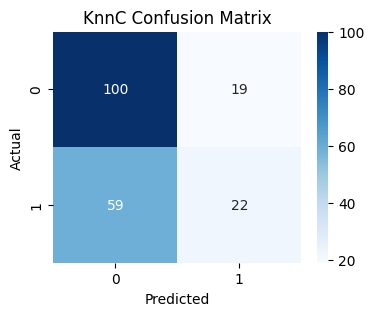

In [0]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(knn_class_results_df["Actual"], knn_class_results_df["Predicted"])

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("KnnC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Reagent Bundles'),
  Text(1, 0, 'Urine/Stool Sample Kits'),
  Text(2, 0, 'Sharps Disposal'),
  Text(3, 0, 'PCR Test Kits'),
  Text(4, 0, 'Pipette Tips'),
  Text(5, 0, 'Blood Collection Kits')])

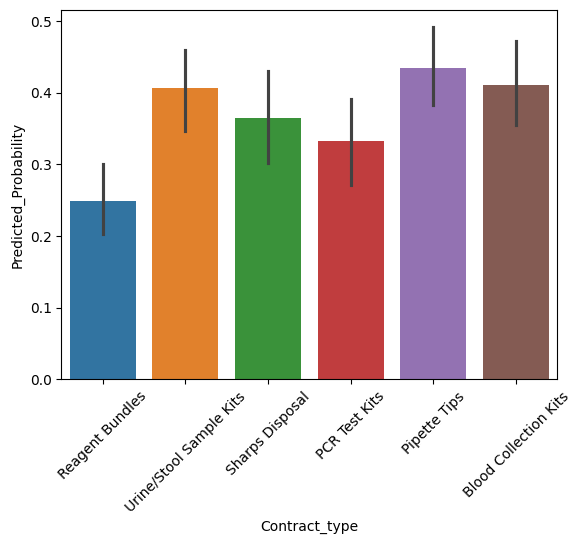

In [0]:
sns.barplot(x='Contract_type', y='Predicted_Probability',hue='Contract_type', data=knn_class_results_df)
plt.xticks(rotation=45)

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0')])

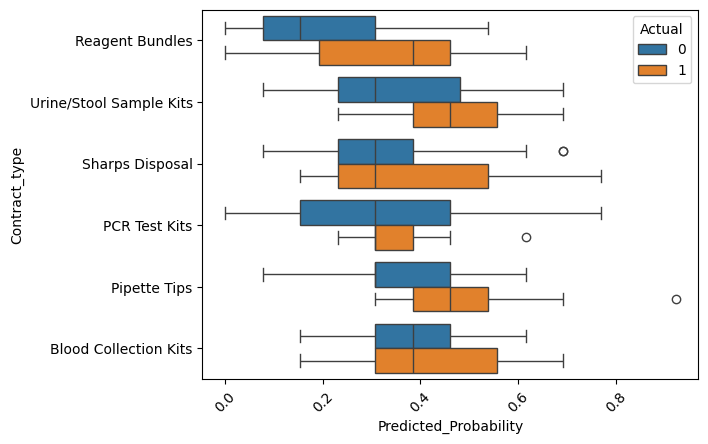

In [0]:
sns.boxplot(x='Predicted_Probability', y='Contract_type',hue='Actual', data=knn_class_results_df)
plt.xticks(rotation=45)

In [0]:
overall_knnc_test_results_df

,Accuracy,Precision,Recall,F1
0,0.61,0.536585,0.271605,0.360656



Accuracy	Precision	Recall	F1
0	0.57	0.446809	0.259259	0.328125.     (7 neighbours)


Accuracy	Precision	Recall	F1
0	0.595	0.5	0.308642	0.381679            (11 neighbours)

Accuracy	Precision	Recall	F1
0	0.61	0.536585	0.271605	0.360656.     (13 neighbours)


Accuracy	Precision	Recall	F1
0	0.615	0.547619	0.283951	0.373984.     (15 neighbours)

<Axes: xlabel='quoted_cost', ylabel='cost_deviation_pct'>

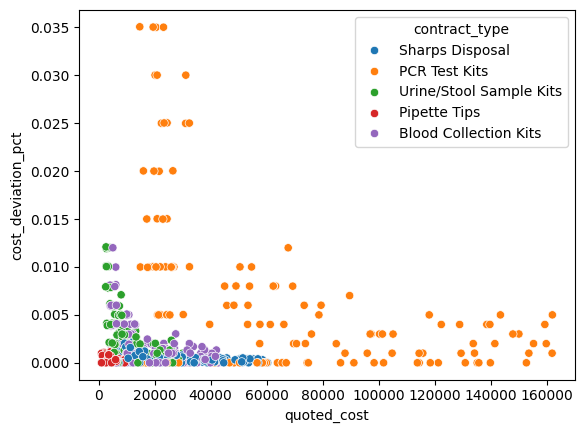

In [0]:
contract_types = ['Sharps Disposal', 'Pipette Tips', 'Urine/Stool Sample Kits', 'Blood Collection Kits', 'PCR Test Kits']

filtered_df = nhs_combo_df_pandas[nhs_combo_df_pandas['contract_type'].isin(contract_types)]

sns.scatterplot(y='cost_deviation_pct', x='quoted_cost', hue='contract_type', data=filtered_df)

In [0]:
nhs_combo_df_pandas.sample()

,contract_id,trust_id,supplier_id,supplier_name,contract_type_id,contract_type,postcode,issue_date,closing_date,trust_name,quoted_lead_days,actual_lead_days,delivery_date,quantity,unit_cost,quoted_cost,actual_cost,cost_overrun,closing_date_month,actual_per_unit_cost,quoted_per_unit_cost,cost_deviation_pct
847,NHS-CT-00848,TR-005,SUP-005,SterileFlow,CTYP-005,Pipette Tips,FY3,2024-08-10,2024-08-26,Blackpool Teaching Hospitals NHS FT,5,9,2024-09-04,50000,0.09,4311.11,4311.14,0.03,August,0.086223,0.086222,0.000696


<Axes: xlabel='postcode', ylabel='cost_deviation_pct'>

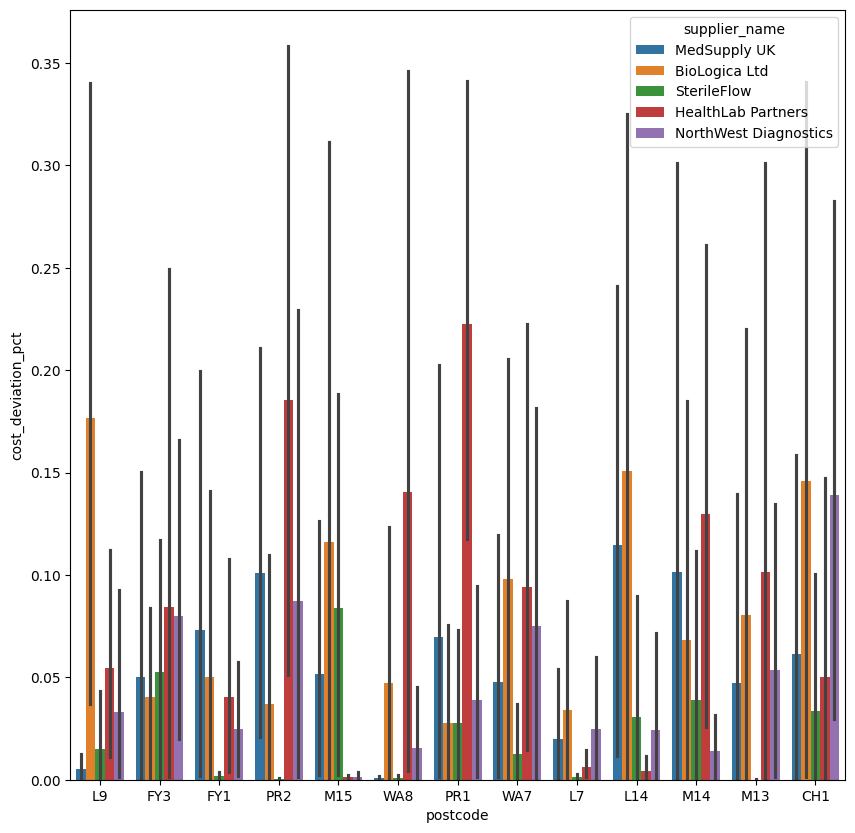

In [0]:
plt.figure(figsize=(10,10))
sns.barplot(x='postcode', y='cost_deviation_pct', hue='supplier_name',data=nhs_combo_df_pandas)

<Axes: xlabel='cost_deviation_pct', ylabel='supplier_name'>

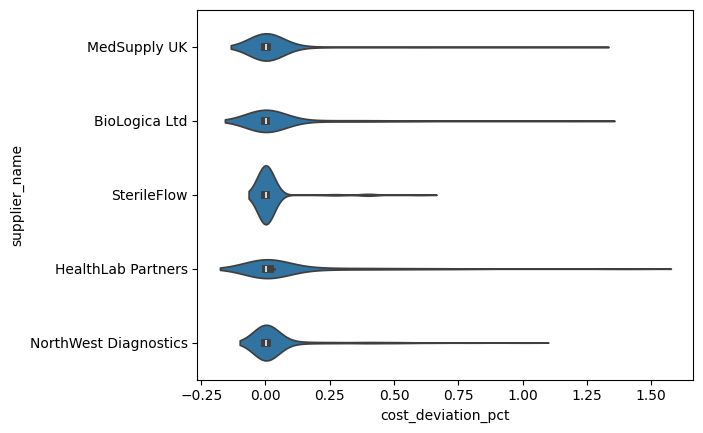

In [0]:
sns.violinplot(x='cost_deviation_pct', y='supplier_name',data=nhs_combo_df_pandas)

In [0]:
nhs_combo_df_pandas['cost_deviation_pct'].min()

np.float64(0.0)

<Axes: xlabel='cost_deviation_pct', ylabel='supplier_name'>

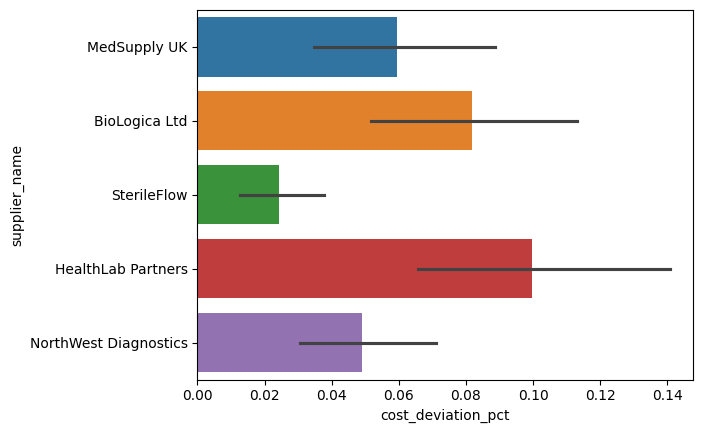

In [0]:
sns.barplot(x='cost_deviation_pct', y='supplier_name',hue='supplier_name', data=nhs_combo_df_pandas)

In [0]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output='pandas')

Spring: March, April, May
Summer: June, July, August
Autumn: September, October, November
Winter: December, January, February 

### Functions

In [0]:
def voting_regr_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test):
    lin_regr_model = LinearRegression()
    knn_regr_model = KNeighborsRegressor(n_neighbors=8)
    rfr_model = RandomForestRegressor(n_estimators=100)
    gbr_model = GradientBoostingRegressor(n_estimators=100)
    
    voting_regr_model = VotingRegressor([('lin', lin_regr_model), ('knn', knn_regr_model), ('rfr', rfr_model), ('gbr', gbr_model)])

    voting_regr_model.fit(X_train_encoded, y_train)
    voting_regr_model.score(X_test_encoded, y_test)

    y_preds_cost = voting_regr_model.predict(X_test_encoded)
    mse = mean_squared_error(y_test, y_preds_cost)
    mae = mean_absolute_error(y_test, y_preds_cost)
    r2 = r2_score(y_test, y_preds_cost)

    voting_regr_results_df = pd.DataFrame({
        "Predicted": y_preds_cost,
        "Actual": y_test.values,
        "Residuals": y_test.values - y_preds_cost,
        "Contract Type": contract_type_test
    })

    overall_voting_regr_results_df = pd.DataFrame([{
        "MSE": mean_squared_error(y_test, y_preds_cost),
        "MAE": mean_absolute_error(y_test, y_preds_cost),
        "R2": r2_score(y_test, y_preds_cost),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_preds_cost))
    }])
    
    return voting_regr_results_df, overall_voting_regr_results_df

def voting_regr_pipeline(df):
    X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test = pp(df)
    return voting_regr_model(X_train_encoded, X_test_encoded, y_train, y_test, contract_type_test)


In [0]:
preprocessor

### Lin regression Model

In [0]:
lin_regr_pp = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Lin_regr", LinearRegression())
])

### SHAP

In [0]:
!pip install shap --upgrade -q
import shap
shap.initjs()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
lin_regr_pp

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['contract_type', 'postcode',
                                                   'closing_date_season',
                                                   'supplier_name']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['quantity',
                                                   'quoted_per_unit_cost',
                                                   'quoted_cost', 'qc_per_day',
                                                   'actual_per_unit_cost',
                                                   'avg_actual_cost_until_closing_date'])])),
                ('Lin_regr', LinearRegression())])

In [0]:
X_train_pp = lin_regr_pp['preprocessor'].transform(X_train)
column_names=X_train_pp.columns
X_test_pp = lin_regr_pp['preprocessor'].transform(X_test)

In [0]:
explainer = shap.Explainer(lin_regr_pp['Lin_regr'], X_train_pp)

In [0]:
explainer

In [0]:
explanations = explainer(X_test_pp)

In [0]:
# Let us have a look at the feature effect assignments to a single prediction
# Assume we would like to investigate the positive class (has diabetes)
cls_idx = 1
# we can investigate a local explanation (positional index is 0)
row_idx = 0

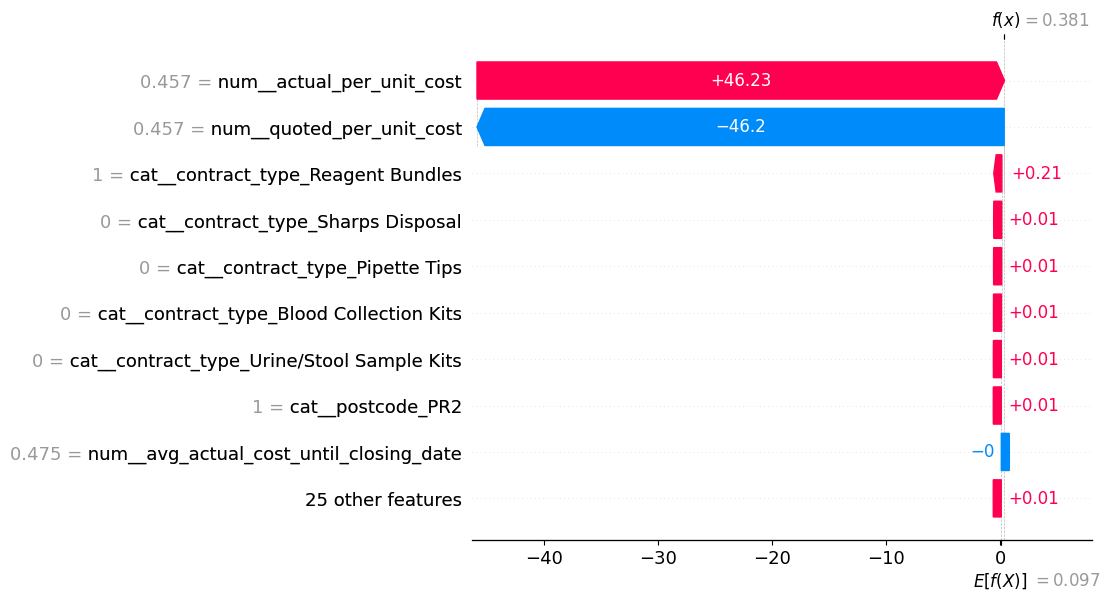

In [0]:
shap.plots.waterfall(explanations[row_idx])

In [0]:
shap.initjs()
shap.plots.force(explanations[row_idx])

In [0]:
shap_values = explainer.shap_values(X_test_pp)


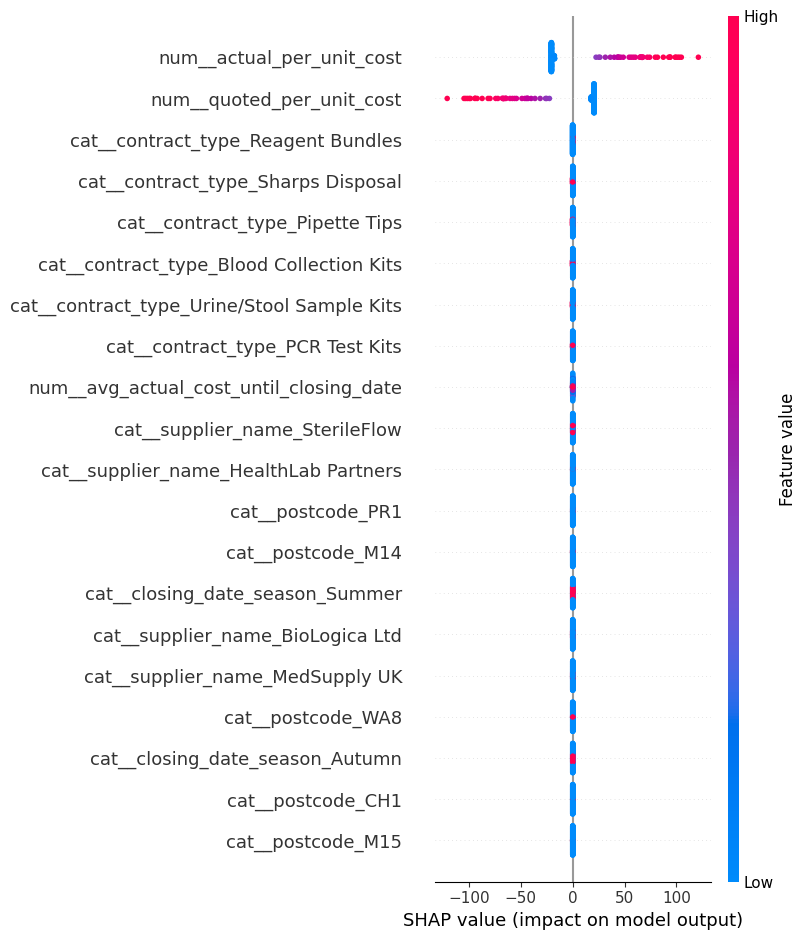

In [0]:
shap.summary_plot(explanations.values, X_test_pp, feature_names=column_names)

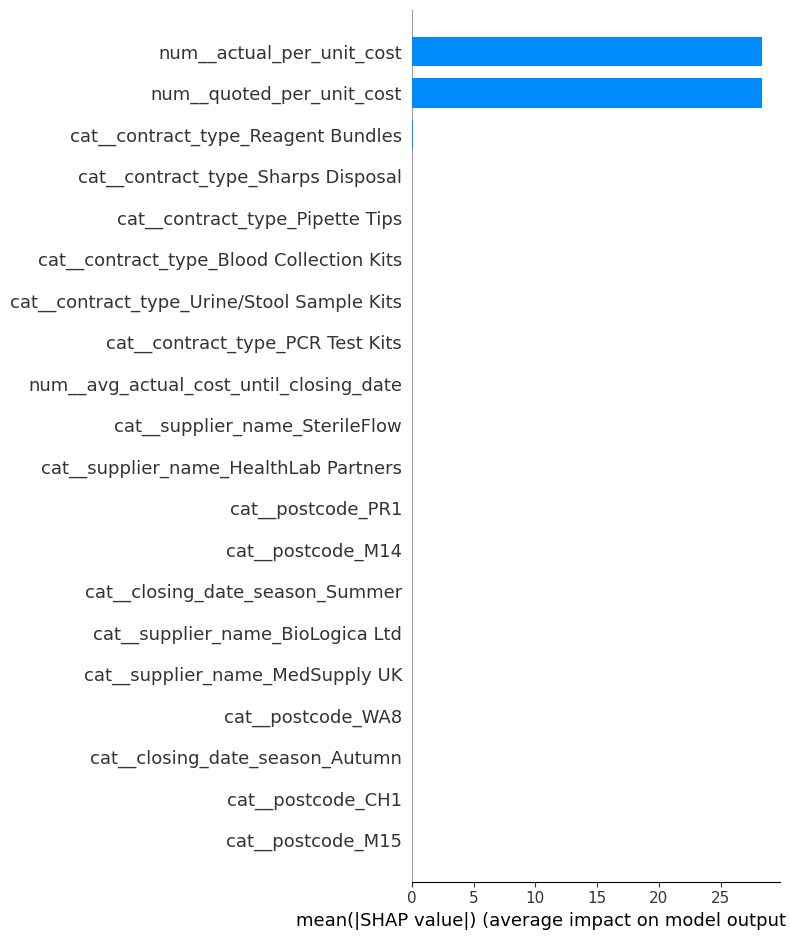

In [0]:
shap.summary_plot(explanations.values, X_test_pp, feature_names=column_names, plot_type="bar")

### Permutation Importance

In [0]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(lin_regr_pp, X_test, y_test, n_repeats=30, random_state=27, scoring='r2')
# n_repeats = number of times shuffled

In [0]:
perm_importance_df = pd.DataFrame(
    dict(
        feature=X_test.columns,
        pi_mean=perm_importance['importances_mean'],
        pi_std=perm_importance['importances_std']
    )
)

In [0]:
perm_importance_df.sort_values('pi_mean', ascending=False)

### PCA + Lin Regr

In [0]:
from sklearn.decomposition import PCA
pca_transformer = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy="mean")),
    ("MinMaxScaler", MinMaxScaler()),
    ("PCA", PCA(n_components=2))
])

pca_pp = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_feat),
        ("num_pca", pca_transformer, num_feat)
    ]
)

In [0]:
pca_lin_regr = Pipeline(steps=[
    ("preprocessor", pca_pp),
    ("Lin_regr", LinearRegression())
])
pca_lin_regr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['contract_type', 'postcode',
                                                   'closing_date_season',
                                                   'supplier_name']),
                                                 ('num_pca',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer()),
                                                                  ('MinMaxScaler',
                                                                   MinMaxScaler()),
                                                                  ('PCA',
                                                                   PCA(n_components=2))]),
                                                  ['quantity',
                                                   'quoted_per_unit_cost',
                                                   'quoted_cost',
                                                   'qc_per_day'])])),
                ('Lin_regr', LinearRegression())])

In [0]:
pca_lin_regr.fit(X_train, y_train)
pca_lin_regr.score(X_test, y_test)

0.4450166923620077

### Random Forest Model

In [0]:
from sklearn.ensemble import RandomForestRegressor
rfr_regr_pp = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rfr", RandomForestRegressor(n_estimators=100, max_depth=5, random_state=27))
])

In [0]:
rfr_regr_pp

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['contract_type', 'postcode',
                                                   'closing_date_season',
                                                   'supplier_name']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['quantity',
                                                   'quoted_per_unit_cost',
                                                   'quoted_cost',
                                                   'qc_per_day'])])),
                ('rfr', RandomForestRegressor(max_depth=5, random_state=27))])

In [0]:
rfr_regr_pp.fit(X_train, y_train)
rfr_regr_pp.score(X_test, y_test)

0.49050459056462503

In [0]:
pca_rfr_regr = Pipeline(steps=[
    ("preprocessor", pca_pp),
    ("rfr", RandomForestRegressor(n_estimators=100, max_depth=5, random_state=27))
])
pca_rfr_regr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['contract_type', 'postcode',
                                                   'closing_date_season',
                                                   'supplier_name']),
                                                 ('num_pca',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer()),
                                                                  ('MinMaxScaler',
                                                                   MinMaxScaler()),
                                                                  ('PCA',
                                                                   PCA(n_components=2))]),
                                                  ['quantity',
                                                   'quoted_per_unit_cost',
                                                   'quoted_cost',
                                                   'qc_per_day'])])),
                ('rfr', RandomForestRegressor(max_depth=5, random_state=27))])

In [0]:
pca_rfr_regr.fit(X_train, y_train)
pca_rfr_regr.score(X_test, y_test)

0.42567443766079394

In [0]:
X_cat_encoded

In [0]:
X_num_encoded

In [0]:
X_train.sample(3)